## Transformer-Enhanced Skin Lesion Classifier (Silver Model)
## **Teammates: Kishore, Ellie Lansdown, Ryan Bennett, Grace Callahan & Stephanie Furst**
## **Team: Group 7 | Modern AI for Business | MSBA | March 2026**

This notebook upgrades the bronze model across three dimensions:
1. **Data diversity** — ISIC 2019 + PAD-UFES-20 + MILK10k (~32,500 images, 9 harmonised classes, multi-country, multi-device, Fitzpatrick I–VI)
2. **Architecture** — three fine-tuned models compared: EfficientNetB0, SwinV2, BiomedCLIP
3. **Evaluation rigour** — focal loss, AUROC, Grad-CAM, and held-out fairness audit on Fitzpatrick17k + DDI (never seen during training)

**Held-out evaluation sets (never trained on):** Fitzpatrick17k · DDI (Stanford)
**Training pool:** ~32,500 images (ISIC 2019 + PAD-UFES-20 + MILK10k dermoscopic stream)


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Imports & Environment Setup

In [6]:
# Core deep learning + utilities
!pip install -q tensorflow keras scikit-learn matplotlib Pillow pandas numpy

# timm — provides SwinV2 (PyTorch)
!pip install -q timm

# open_clip — provides BiomedCLIP (PyTorch)
!pip install -q open_clip_torch

# grad-cam — clean Grad-CAM for PyTorch models
!pip install -q grad-cam

print('All packages installed.')


All packages installed.


In [7]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as mpl_cm
warnings.filterwarnings('ignore')

# TensorFlow / Keras (EfficientNetB0)
import tensorflow as tf
from tensorflow.keras import mixed_precision
from tensorflow.keras.layers import (Dense, Dropout, GlobalAveragePooling2D,
                                      BatchNormalization, Input)
from tensorflow.keras.callbacks import (ModelCheckpoint, EarlyStopping,
                                         ReduceLROnPlateau)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# PyTorch (SwinV2 + BiomedCLIP)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm
import open_clip

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, balanced_accuracy_score)
from sklearn.preprocessing import label_binarize

from PIL import Image

# Device flags
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'TF version   : {tf.__version__}')
print(f'PyTorch      : {torch.__version__}')
print(f'CUDA device  : {DEVICE}')
print(f'GPU available: {torch.cuda.is_available()}')

TF version   : 2.19.0
PyTorch      : 2.10.0+cu128
CUDA device  : cuda
GPU available: True


In [ ]:
# Enable TF mixed precision — weights stay float32, compute runs in float16
# Gives ~1.5x speedup on T4/A100 with no accuracy loss
mixed_precision.set_global_policy('mixed_float16')
print('Mixed precision policy:', mixed_precision.global_policy().name)

# PyTorch equivalent — autocast used inside training loop per batch
torch.backends.cuda.matmul.allow_tf32 = True


In [8]:
# utilities shared across all three models

def plot_learning_curve(history, title=''):
    """Works for both Keras History objects and plain dicts with the same keys."""
    h = history.history if hasattr(history, 'history') else history
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(h['accuracy'] if 'accuracy' in h else h['train_acc'], label='train')
    axes[0].plot(h['val_accuracy'] if 'val_accuracy' in h else h['val_acc'], label='val')
    axes[0].set(title=f'Accuracy — {title}', xlabel='epoch', ylabel='accuracy')
    axes[0].legend()

    axes[1].plot(h['loss'] if 'loss' in h else h['train_loss'], label='train')
    axes[1].plot(h['val_loss'], label='val')
    axes[1].set(title=f'Loss — {title}', xlabel='epoch', ylabel='loss')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(cm, label_names, title='Confusion Matrix'):
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.colorbar(im)
    ax.set(xticks=np.arange(len(label_names)),
           yticks=np.arange(len(label_names)),
           xticklabels=label_names, yticklabels=label_names,
           ylabel='True label', xlabel='Predicted label', title=title)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    thresh = cm.max() / 2
    for i in range(len(label_names)):
        for j in range(len(label_names)):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black', fontsize=8)
    plt.tight_layout()
    plt.show()


def print_auroc(y_true, y_prob, label_names):
    """Print per-class and macro AUROC — one-vs-rest."""
    n = len(label_names)
    y_bin = label_binarize(y_true, classes=list(range(n)))
    print(f'  {"Class":<8} {"AUROC":>8}')
    print('  ' + '-' * 18)
    for i, cls in enumerate(label_names):
        auc = roc_auc_score(y_bin[:, i], y_prob[:, i])
        print(f'  {cls:<8} {auc:>8.4f}')
    macro = roc_auc_score(y_bin, y_prob, average='macro')
    print(f'  {"Macro":<8} {macro:>8.4f}')
    return macro


def evaluate_predictions(y_true, y_pred, y_prob, label_names, model_name):
    """Full healthcare-focused evaluation: report + confusion matrix + AUROC."""
    print(f'\n=== {model_name} — Classification Report ===')
    print(classification_report(y_true, y_pred, target_names=label_names, digits=4))
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    print(f'  Balanced accuracy (macro-avg recall): {bal_acc:.4f}')
    print(f'\n=== {model_name} — AUROC ===')
    macro_auc = print_auroc(y_true, y_prob, label_names)
    plot_confusion_matrix(confusion_matrix(y_true, y_pred), label_names,
                          title=f'Confusion Matrix — {model_name}')
    return bal_acc, macro_auc


## 2. Dataset Loading & Label Harmonisation

### Why multiple datasets?
The bronze model (HAM10000 only) was trained almost exclusively on dermoscopic images of
Fitzpatrick I–III patients from Australia and Austria.  A 25-year-old Black woman with a lesion on
her foot barely exists in that training distribution — so the bronze model would be unreliable for her.

### Silver training pool
| Dataset | Images | Device | Origin | Fitzpatrick |
|---|---|---|---|---|
| ISIC 2019 | ~25,000 | Dermoscope | Multi-country | Implicit (I–III dominant) |
| PAD-UFES-20 | 2,298 | Smartphone | Brazil | Explicit I–VI labels |
| MILK10k (derm only) | 5,240 | Dermoscope | Multi-site | Diverse |
| **Combined** | **~32,500** | **Multi-device** | **Multi-country** | **I–VI** |

### 9 harmonised classes
`mel · nv · bcc · scc · akiec · bkl · df · vasc · unk`
SCC absorbs Bowen's disease from PAD-UFES-20. BKL absorbs SEK (seborrhoeic keratosis).
`unk` captures any MILK10k-specific label with no ISIC equivalent.


In [3]:
import kagglehub
path = kagglehub.dataset_download("andrewmvd/isic-2019")

Using Colab cache for faster access to the 'isic-2019' dataset.


In [80]:
import kagglehub
import os

print("Downloading datasets from Kaggle...")

# 1. ISIC 2019
isic_2019_path = kagglehub.dataset_download("andrewmvd/isic-2019")
ISIC2019_IMG_DIR  = os.path.join(isic_2019_path, 'ISIC_2019_Training_Input', 'ISIC_2019_Training_Input')
ISIC2019_LABEL_CSV = os.path.join(isic_2019_path, 'ISIC_2019_Training_GroundTruth.csv')
ISIC2019_META_CSV  = os.path.join(isic_2019_path, 'ISIC_2019_Training_Metadata.csv')

# 2. PAD-UFES-20
pad_path = kagglehub.dataset_download("mahdavi1202/skin-cancer")
PADUFES_IMG_DIR  = os.path.join(pad_path, 'images')
PADUFES_META_CSV = os.path.join(pad_path, 'metadata.csv')

# 3. MILK10k ISIC Challenge 2025
milk_path = kagglehub.dataset_download("nguyenphucduyloc/milk10k-isic-challenge-2025")
# Adjust these internal paths based on the exact structure of the downloaded dataset
MILK10K_IMG_DIR  = os.path.join(milk_path, 'dermoscopic')
MILK10K_META_CSV = os.path.join(milk_path, 'metadata_derm.csv')

# 4. Fitzpatrick17k
fitz_path = kagglehub.dataset_download("nazmusresan/fitzpatrick17k")
FITZ17K_IMG_DIR  = os.path.join(fitz_path, 'images')
FITZ17K_META_CSV = os.path.join(fitz_path, 'fitzpatrick17k.csv')

# 5. DDI (Diverse Dermatology Images)
ddi_path = kagglehub.dataset_download("souvikda/ddidiversedermatology-multimodal-dataset")
DDI_IMG_DIR      = os.path.join(ddi_path, 'images')
DDI_META_CSV     = os.path.join(ddi_path, 'ddi_metadata.csv')

print('\nPaths configured via Kagglehub. You might need to verify the exact internal folder names if file loading fails.')


Using Colab cache for faster access to the 'isic-2019' dataset.
Using Colab cache for faster access to the 'skin-cancer' dataset.
Using Colab cache for faster access to the 'milk10k-isic-challenge-2025' dataset.


100%|██████████| 1.23G/1.23G [01:28<00:00, 14.9MB/s]

Extracting files...


Using Colab cache for faster access to the 'ddidiversedermatology-multimodal-dataset' dataset.

Paths configured via Kagglehub. You might need to verify the exact internal folder names if file loading fails.


In [24]:
# 9-class unified label map
# All source dataset labels are normalised to lowercase ISIC-style abbreviations
# Bowen's disease in PAD-UFES-20 appears as SCC (already merged by that dataset)
# SEK (seborrhoeic keratosis) → bkl (both are benign keratosis-like)

LABEL_MAP = {
    # ISIC 2019 column headers → target
    'MEL': 'mel',  'NV': 'nv',    'BCC': 'bcc',  'AK':   'akiec',
    'BKL': 'bkl',  'DF': 'df',    'VASC': 'vasc', 'SCC':  'scc',

    # PAD-UFES-20 diagnostic column values
    'NEV': 'nv',   'ACK': 'akiec', 'SEK': 'bkl',

    # Pass-through (already lowercase)
    'mel': 'mel',  'nv': 'nv',    'bcc': 'bcc',  'akiec': 'akiec',
    'bkl': 'bkl',  'df': 'df',    'vasc': 'vasc', 'scc':  'scc'}

# Ordered label list — used everywhere (class index is positional)
# Risk tiers: HIGH = mel, bcc, scc | MODERATE = akiec | LOW = nv, bkl, df, vasc
LABEL_NAMES = ['mel', 'nv', 'bcc', 'scc', 'akiec', 'bkl', 'df', 'vasc', 'unk']
N_CLASSES   = len(LABEL_NAMES)
LABEL2IDX   = {l: i for i, l in enumerate(LABEL_NAMES)}

RISK_COLORS = {'mel': '#d62728', 'bcc': '#d62728', 'scc': '#d62728',
    'akiec': '#ff7f0e','nv': '#2ca02c', 'bkl': '#2ca02c', 'df': '#2ca02c', 'vasc': '#2ca02c',
    'unk': '#7f7f7f'}

print(f'Classes ({N_CLASSES}):', LABEL_NAMES)


Classes (9): ['mel', 'nv', 'bcc', 'scc', 'akiec', 'bkl', 'df', 'vasc', 'unk']


In [25]:
# Loading ISIC 2019
# Ground truth CSV has one-hot columns: image, MEL, NV, BCC, AK, BKL, DF, VASC, SCC, UNK
# We argmax across the class columns to recover a single label per row

isic_gt = pd.read_csv(ISIC2019_LABEL_CSV)

isic_class_cols = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK']
# Keep only columns that exist in this version of the CSV
isic_class_cols = [c for c in isic_class_cols if c in isic_gt.columns]

isic_gt['raw_label'] = isic_gt[isic_class_cols].idxmax(axis=1)
isic_gt['label']     = isic_gt['raw_label'].map(LABEL_MAP).fillna('unk')
isic_gt['path']      = isic_gt['image'].apply(
    lambda x: os.path.join(ISIC2019_IMG_DIR, x + '.jpg'))
isic_gt['source']    = 'isic2019'

# Optional: merge age/sex metadata if available
if os.path.exists(ISIC2019_META_CSV):
    isic_meta = pd.read_csv(ISIC2019_META_CSV)
    isic_gt   = isic_gt.merge(isic_meta[['image', 'age_approx', 'sex', 'anatom_site_general']],
                               on='image', how='left')

isic_df = isic_gt[['image', 'path', 'label', 'source']].copy()
isic_df = isic_df[isic_df['path'].apply(os.path.exists)]  # drop rows with missing images

print(f'ISIC 2019 — rows loaded  : {len(isic_df):,}')
print(isic_df['label'].value_counts())


ISIC 2019 — rows loaded  : 25,331
label
nv       12875
mel       4522
bcc       3323
bkl       2624
akiec      867
scc        628
vasc       253
df         239
Name: count, dtype: int64


In [18]:
# Loading PAD-UFES-20
# Metadata CSV has 26 columns; key ones: img_id, diagnostic, fitzpatrick
# diagnostic values: MEL, NEV, BCC, SCC, ACK, SEK
# NOTE: PAD-UFES-20 has full Fitzpatrick labels — we preserve this column
#       and use it later for the within-training-set fairness checks

padufes_meta = pd.read_csv(PADUFES_META_CSV)

# Standardising column names across dataset versions
if 'img_id' in padufes_meta.columns:
    padufes_meta = padufes_meta.rename(columns={'img_id': 'image'})
if 'patient_id' not in padufes_meta.columns:
    padufes_meta['patient_id'] = padufes_meta.index  # fallback if no patient column

padufes_meta['label']  = padufes_meta['diagnostic'].str.upper().map(LABEL_MAP).fillna('unk')

# Robust image finder using os.walk to handle unpredictable Kaggle folder nesting
print('Scanning PAD-UFES-20 directory for images...')
img_path_map = {}
for root, _, files in os.walk(pad_path):
    for f in files:
        if f.endswith(('.png', '.jpg', '.jpeg', '.JPG', '.PNG')):
            img_path_map[f] = os.path.join(root, f)

padufes_meta['path']   = padufes_meta['image'].map(img_path_map)
padufes_meta['source'] = 'padufes20'

# Preserving fitzpatrick column for fairness audit
fitz_col = 'fitzpatrick' if 'fitzpatrick' in padufes_meta.columns else None

padufes_df = padufes_meta[['image', 'path', 'label', 'source']].copy()
if fitz_col:
    padufes_df['fitzpatrick'] = padufes_meta[fitz_col].values

# Dropping rows where the image file was not found
padufes_df = padufes_df.dropna(subset=['path'])

print(f'PAD-UFES-20 — rows loaded: {len(padufes_df):,}')
print(padufes_df['label'].value_counts())

Scanning PAD-UFES-20 directory for images...
PAD-UFES-20 — rows loaded: 2,298
label
bcc      845
akiec    730
nv       244
bkl      235
scc      192
mel       52
Name: count, dtype: int64


In [16]:
import os
import pandas as pd

print(" === PAD-UFES-20 Data Strcuture ===")
print(f"Base path: {pad_path}")
try:
    print(f"Root contents: {os.listdir(pad_path)}")
except Exception as e:
    print(e)

if os.path.exists(PADUFES_IMG_DIR):
    imgs = os.listdir(PADUFES_IMG_DIR)
    print(f"\nImages dir exists. First 5 files: {imgs[:5]}")
else:
    print(f"\nImages dir does NOT exist: {PADUFES_IMG_DIR}")

print("\n=== Metadata Preview ===")
if os.path.exists(PADUFES_META_CSV):
    debug_meta = pd.read_csv(PADUFES_META_CSV)
    display(debug_meta.head(3))
else:
    print(f"Metadata CSV does NOT exist at: {PADUFES_META_CSV}")

=== PAD-UFES-20 Dataset Structure ===
Base path: /root/.cache/kagglehub/datasets/mahdavi1202/skin-cancer/versions/1
Root contents: ['imgs_part_2', 'imgs_part_3', 'metadata.csv', 'imgs_part_1']

Images dir does NOT exist: /root/.cache/kagglehub/datasets/mahdavi1202/skin-cancer/versions/1/images

=== Metadata Preview ===


,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,...,diameter_2,diagnostic,itch,grew,hurt,changed,bleed,elevation,img_id,biopsed
0,PAT_1516,1765,NaN,NaN,NaN,NaN,8,NaN,NaN,NaN,...,NaN,NEV,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,PAT_1516_1765_530.png,False
1,PAT_46,881,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,...,5.0,BCC,TRUE,TRUE,FALSE,TRUE,TRUE,TRUE,PAT_46_881_939.png,True
2,PAT_1545,1867,NaN,NaN,NaN,NaN,77,NaN,NaN,NaN,...,NaN,ACK,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,PAT_1545_1867_547.png,False


In [28]:
milk_path = kagglehub.dataset_download("nguyenphucduyloc/milk10k-isic-challenge-2025")
# Adjust these internal paths based on the exact structure of the downloaded dataset
MILK10K_IMG_DIR  = os.path.join(milk_path, 'dermoscopic')
MILK10K_META_CSV = os.path.join(milk_path, 'metadata_derm.csv')

Using Colab cache for faster access to the 'milk10k-isic-challenge-2025' dataset.


In [32]:
# Load MILK10k (dermoscopic stream only)
import os
import pandas as pd

# 1. Dynamically find the metadata CSV
print(f"Scanning for MILK10k metadata in: {milk_path}")
found_csvs = []
for root_dir, _, files in os.walk(milk_path):
    for f in files:
        if f.endswith('.csv') and 'GroundTruth' in f:
            found_csvs.append(os.path.join(root_dir, f))

# fallback to any CSV if ground truth is not found
if not found_csvs:
    for root_dir, _, files in os.walk(milk_path):
        for f in files:
            if f.endswith('.csv'):
                found_csvs.append(os.path.join(root_dir, f))

if not os.path.exists(MILK10K_META_CSV):
    if found_csvs:
        MILK10K_META_CSV = found_csvs[0]  # Use the first found CSV
        print(f"Falling back to found CSV: {MILK10K_META_CSV}")
    else:
        raise FileNotFoundError("No CSV files found in the MILK10k directory!")

milk_meta = pd.read_csv(MILK10K_META_CSV)

# 2. Dynamically map image paths and extract lesion_id from folder names
print('Scanning MILK10k directory for images...')
image_records = []
for root_dir, _, files in os.walk(milk_path):
    for f in files:
        if f.endswith(('.png', '.jpg', '.jpeg', '.JPG', '.PNG')):
            path = os.path.join(root_dir, f)
            isic_id = os.path.splitext(f)[0]
            lesion_id = os.path.basename(root_dir)  # folder name is usually the lesion_id
            image_records.append({'image': isic_id, 'path': path, 'lesion_id': lesion_id})

img_df = pd.DataFrame(image_records)

# Merge image paths with metadata
if 'lesion_id' in milk_meta.columns and 'image' not in milk_meta.columns and 'isic_id' not in milk_meta.columns:
    milk_meta = milk_meta.merge(img_df, on='lesion_id', how='inner')
elif 'isic_id' in milk_meta.columns:
    milk_meta['image'] = milk_meta['isic_id']
    milk_meta = milk_meta.merge(img_df[['image', 'path']], on='image', how='inner')
elif 'image_id' in milk_meta.columns:
    milk_meta['image'] = milk_meta['image_id']
    milk_meta = milk_meta.merge(img_df[['image', 'path']], on='image', how='inner')
else:
    # Fallback to matching image ids if columns are completely unknown
    milk_meta['image'] = milk_meta.iloc[:, 0]
    milk_meta = milk_meta.merge(img_df[['image', 'path']], on='image', how='inner')

# Handle labels (one-hot vs string)
if 'label' in milk_meta.columns:
    milk_meta['label']  = milk_meta['label'].str.lower().map(LABEL_MAP).fillna('unk')
else:
    # Extract one-hot encoded columns (ignoring identifier columns)
    disease_cols = [c for c in milk_meta.columns if c not in ['image', 'isic_id', 'image_id', 'lesion_id', 'split', 'path']]
    milk_meta['raw_label'] = milk_meta[disease_cols].idxmax(axis=1)

    # Temporary custom map for MILK10k specific one-hot column names
    milk_map = LABEL_MAP.copy()
    milk_map.update({'SCCKA': 'scc', 'BEN_OTH': 'unk', 'MAL_OTH': 'unk'})

    milk_meta['label'] = milk_meta['raw_label'].map(milk_map).fillna('unk')

milk_meta['source'] = 'milk10k'

milk_df = milk_meta[['image', 'path', 'label', 'source']].copy()
milk_df = milk_df.dropna(subset=['path'])  # Drop rows where images weren't found

print(f'\nMILK10k (derm) — rows loaded: {len(milk_df):,}')
print(milk_df['label'].value_counts())

Scanning for MILK10k metadata in: /kaggle/input/milk10k-isic-challenge-2025
Scanning MILK10k directory for images...

MILK10k (derm) — rows loaded: 10,480
label
bcc     5044
nv      1492
bkl     1088
scc      946
mel      900
unk      812
df       104
vasc      94
Name: count, dtype: int64


In [33]:
# Image ID overlap check — CRITICAL before combining
# ISIC 2019 contains images from HAM10000 and BCN20000 under the same image IDs.

# If we blindly concatenate, the same image can appear in both train and test, causing artificially inflated metrics (data leakage).

isic_ids   = set(isic_df['image'])
padufes_ids = set(padufes_df['image'])
milk_ids    = set(milk_df['image'])

overlap_ip  = isic_ids & padufes_ids
overlap_im  = isic_ids & milk_ids
overlap_pm  = padufes_ids & milk_ids

print(f'ISIC 2019 images       : {len(isic_ids):,}')
print(f'PAD-UFES-20 images     : {len(padufes_ids):,}')
print(f'MILK10k images         : {len(milk_ids):,}')
print()
print(f'Overlap ISIC ∩ PAD-UFES: {len(overlap_ip)}  (expected ~0 — different institutions)')
print(f'Overlap ISIC ∩ MILK10k : {len(overlap_im)}  (check — may share ISIC archive IDs)')
print(f'Overlap PAD ∩ MILK10k  : {len(overlap_pm)}  (expected ~0)')

# Drop duplicates - keep ISIC 2019 version as authoritative if IDs collide
if overlap_im:
    print(f'\nDropping {len(overlap_im)} MILK10k rows that share an ID with ISIC 2019...')
    milk_df = milk_df[~milk_df['image'].isin(overlap_im)]
    print(f'MILK10k after dedup: {len(milk_df):,}')


ISIC 2019 images       : 25,331
PAD-UFES-20 images     : 2,298
MILK10k images         : 10,480

Overlap ISIC ∩ PAD-UFES: 0  (expected ~0 — different institutions)
Overlap ISIC ∩ MILK10k : 0  (check — may share ISIC archive IDs)
Overlap PAD ∩ MILK10k  : 0  (expected ~0)


In [34]:
# Combining all three sources into one master DataFrame
metadata = pd.concat([isic_df, padufes_df, milk_df], ignore_index=True)

# Drop any remaining rows where the image file is missing
metadata = metadata[metadata['path'].apply(os.path.exists)].reset_index(drop=True)

# Add integer label index — used by PyTorch DataLoaders
metadata['label_idx'] = metadata['label'].map(LABEL2IDX).fillna(LABEL2IDX.get('unk', 8)).astype(int)

print(f'\nCombined training pool: {len(metadata):,} images')
print(f'Sources: {metadata["source"].value_counts().to_dict()}')
print(f'\nClass distribution (combined — run this BEFORE setting weights):')
print(metadata['label'].value_counts())
print()
print('Percentage breakdown:')
print((metadata['label'].value_counts(normalize=True) * 100).round(2))



Combined training pool: 38,109 images
Sources: {'isic2019': 25331, 'milk10k': 10480, 'padufes20': 2298}

Class distribution (combined — run this BEFORE setting weights):
label
nv       14611
bcc       9212
mel       5474
bkl       3947
scc       1766
akiec     1597
unk        812
vasc       347
df         343
Name: count, dtype: int64

Percentage breakdown:
label
nv       38.34
bcc      24.17
mel      14.36
bkl      10.36
scc       4.63
akiec     4.19
unk       2.13
vasc      0.91
df        0.90
Name: proportion, dtype: float64


## 3. Exploratory Data Analysis (EDA)

Before computing class weights we must inspect the *combined* distribution - not each dataset individually.
The imbalance profile of a stack of three datasets is unpredictable without running `value_counts()` first.


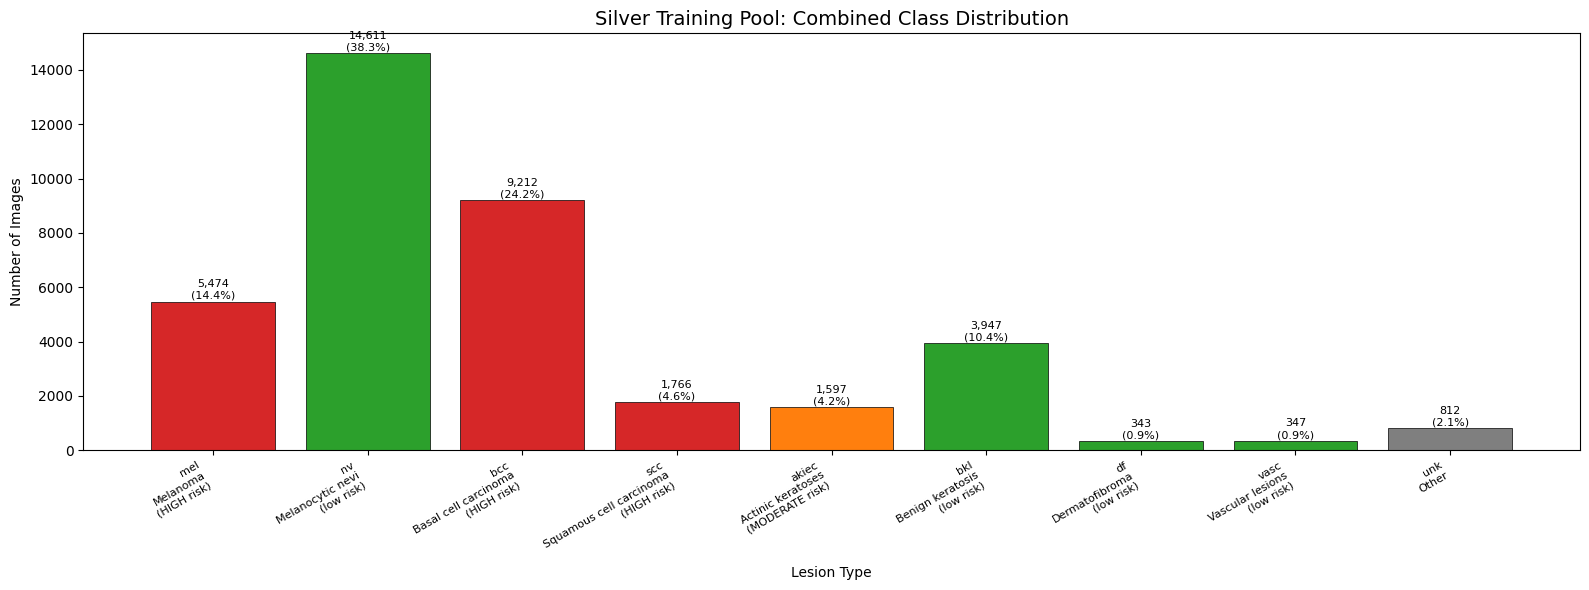

In [36]:
# Combined class distribution
class_counts = metadata['label'].value_counts().reindex(LABEL_NAMES, fill_value=0)

risk_labels = {
    'mel':   'mel\nMelanoma\n(HIGH risk)',
    'nv':    'nv\nMelanocytic nevi\n(low risk)',
    'bcc':   'bcc\nBasal cell carcinoma\n(HIGH risk)',
    'scc':   'scc\nSquamous cell carcinoma\n(HIGH risk)',
    'akiec': 'akiec\nActinic keratoses\n(MODERATE risk)',
    'bkl':   'bkl\nBenign keratosis\n(low risk)',
    'df':    'df\nDermatofibroma\n(low risk)',
    'vasc':  'vasc\nVascular lesions\n(low risk)',
    'unk':   'unk\nOther',
}

bar_colors = [RISK_COLORS[l] for l in LABEL_NAMES]

plt.figure(figsize=(16, 6))
bars = plt.bar(LABEL_NAMES, class_counts.values, color=bar_colors,
               edgecolor='black', linewidth=0.5)
plt.title('Silver Training Pool: Combined Class Distribution', fontsize=14)
plt.xlabel('Lesion Type')
plt.ylabel('Number of Images')
plt.xticks(range(len(LABEL_NAMES)),
           [risk_labels[l] for l in LABEL_NAMES], rotation=30, ha='right', fontsize=8)

for bar, count in zip(bars, class_counts.values):
    pct = count / len(metadata) * 100
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


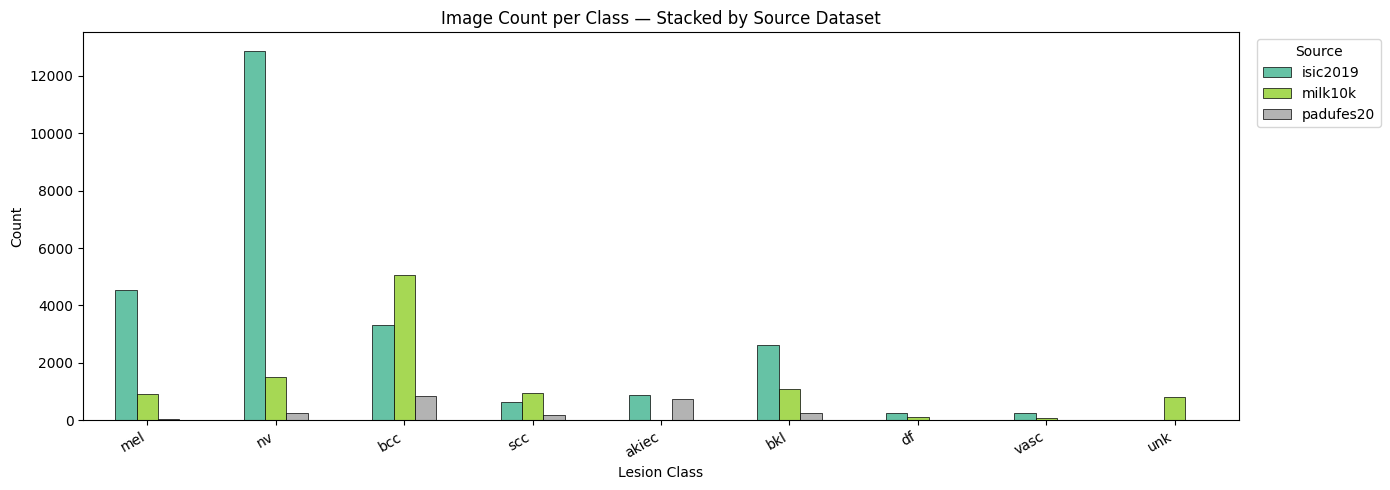

In [37]:
# Per-dataset contribution per class
pivot = (metadata.groupby(['label', 'source'])
         .size().unstack(fill_value=0)
         .reindex(LABEL_NAMES, fill_value=0))

pivot.plot(kind='bar', figsize=(14, 5), colormap='Set2', edgecolor='black', linewidth=0.5)
plt.title('Image Count per Class: Stacked by Source Dataset')
plt.xlabel('Lesion Class')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Source', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [38]:
# Fitzpatrick skin type distribution (PAD-UFES-20 subset)
# PAD-UFES-20 is the only source with explicit Fitzpatrick labels (thinking about this one)
# This distribution informs whether the combined pool has sufficient darker-skin coverage.

if 'fitzpatrick' in metadata.columns:
    fitz_counts = metadata['fitzpatrick'].dropna().value_counts().sort_index()
    plt.figure(figsize=(8, 4))
    plt.bar(fitz_counts.index.astype(str), fitz_counts.values, color='#5c85d6', edgecolor='black')
    plt.title('Fitzpatrick Skin Type Distribution (PAD-UFES-20 subset)')
    plt.xlabel('Fitzpatrick Type')
    plt.ylabel('Count')
    for i, (idx, v) in enumerate(fitz_counts.items()):
        plt.text(i, v + 5, str(v), ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print('Fitzpatrick column not present — PAD-UFES-20 metadata may need re-merging.')
    print('The held-out Fitzpatrick17k audit (Section 12) does not depend on this column.')


Fitzpatrick column not present — PAD-UFES-20 metadata may need re-merging.
The held-out Fitzpatrick17k audit (Section 12) does not depend on this column.


### EDA Observations

- **nv still dominates** the combined pool - but less severely than bronze's 67% (HAM10000 alone).
  PAD-UFES-20 skews toward BCC and SCC; ISIC 2019 has its own imbalance profile.
- **mel + bcc + scc** are the clinically critical classes. A false negative here (missed cancer) costs far
  more than a false negative in nv (missed benign nevus). This justifies both focal loss and
  risk-informed class weights.
- **Fitzpatrick coverage**: PAD-UFES-20 brings Fitzpatrick IV–VI representation that is almost absent
  from HAM10000 and ISIC 2019. The held-out Fitzpatrick17k audit will quantify whether
  this coverage translates to equitable performance.
- **Key metric**: We optimise for **recall** (sensitivity) on mel, bcc, scc. Accuracy is reported
  but is not the primary objective - a model that achieves 80% accuracy by missing every melanoma
  is clinically useless.


## 4. Train / Validation / Test Split

We use a **70 / 15 / 15 stratified split** - the same ratio as the bronze model.
Stratification ensures every class is proportionally represented in all three sets,
preventing the model from accidentally evaluating on an unseen class distribution.

> **Note on ISIC 2019 patient leakage**: ISIC 2019 does not expose patient IDs in the
> public label CSV. We therefore stratify on label only. If your download includes
> a patient ID column, replace the split below with a patient-level group split
> to prevent the same patient appearing in both train and test.


In [39]:
# Stratified 70 / 15 / 15 split — same pattern as bronze model
train_meta, temp_meta = train_test_split(
    metadata, test_size=0.30,
    stratify=metadata['label'], random_state=42
)
val_meta, test_meta = train_test_split(
    temp_meta, test_size=0.50,
    stratify=temp_meta['label'], random_state=42
)

train_meta = train_meta.reset_index(drop=True)
val_meta   = val_meta.reset_index(drop=True)
test_meta  = test_meta.reset_index(drop=True)

print(f'Train : {len(train_meta):6,} images  ({len(train_meta)/len(metadata)*100:.1f}%)')
print(f'Val   : {len(val_meta):6,} images  ({len(val_meta)/len(metadata)*100:.1f}%)')
print(f'Test  : {len(test_meta):6,} images  ({len(test_meta)/len(metadata)*100:.1f}%)')
print()
print('Class distribution in train set:')
print(train_meta['label'].value_counts(normalize=True).round(3) * 100)


Train : 26,676 images  (70.0%)
Val   :  5,716 images  (15.0%)
Test  :  5,717 images  (15.0%)

Class distribution in train set:
label
nv       38.3
bcc      24.2
mel      14.4
bkl      10.4
scc       4.6
akiec     4.2
unk       2.1
vasc      0.9
df        0.9
Name: proportion, dtype: float64


In [40]:
# Risk-informed class weights
# Computed on the COMBINED training distribution — not per dataset individually.
# This is critical: if we average weights computed separately per dataset,
# the final weight vector will not reflect the actual imbalance in the training pool.

classes_arr = np.array(LABEL_NAMES)
weights_arr  = compute_class_weight(class_weight='balanced', classes=classes_arr, y=train_meta['label'])

# Boost mel, bcc, scc further — clinical cost of a false negative is severe
RISK_BOOST = {'mel': 1.5, 'bcc': 1.3, 'scc': 1.3}
for cls, boost in RISK_BOOST.items():
    idx = LABEL2IDX[cls]
    weights_arr[idx] *= boost

class_weight_dict  = {i: float(w) for i, w in enumerate(weights_arr)}
class_weight_tf    = tf.constant(weights_arr, dtype=tf.float32)   # for TF focal loss
class_weight_torch = torch.tensor(weights_arr, dtype=torch.float32).to(DEVICE)  # for PyTorch

print('Class weights (higher = model penalised more for missing this class):')
print(f'  {"Class":<8} {"Weight":>8}')
print('  ' + '-' * 18)
for cls, w in zip(LABEL_NAMES, weights_arr):
    boost_flag = ' ← risk-boosted' if cls in RISK_BOOST else ''
    print(f'  {cls:<8} {w:>8.4f}{boost_flag}')


Class weights (higher = model penalised more for missing this class):
  Class      Weight
  ------------------
  mel        1.1602 ← risk-boosted
  nv         0.2898
  bcc        0.5976 ← risk-boosted
  scc        3.1175 ← risk-boosted
  akiec      2.6512
  bkl        1.0727
  df        12.3500
  vasc      12.1975
  unk        5.2183


## 5. Focal Loss

**Why focal loss instead of plain categorical cross-entropy?**

Standard cross-entropy treats every sample equally. With a heavily imbalanced dataset,
the model still learns to predict the majority class (nv) confidently, accumulating large
gradient signal from easy correct predictions and drowning out the harder minority classes.

**Focal loss** adds a modulating factor `(1 − p_t)^γ` that down-weights the loss for
easy examples (where the model is already confident) and concentrates learning on hard,
uncertain examples — exactly the rare, ambiguous melanomas and BCCs we care most about.

```
FL(p_t) = −α_t · (1 − p_t)^γ · log(p_t)
    γ = 2.0  (standard; higher → more focus on hard examples)
    α = class weights computed above (higher for rare high-risk classes)
```

Combined with class weights (`α`), focal loss gives us two simultaneous corrections:
class frequency imbalance (via `α`) and example difficulty imbalance (via `γ`).


In [41]:
# ── Focal Loss — TensorFlow / Keras ──────────────────────────────────────────

class FocalLoss(tf.keras.losses.Loss):
    """
    Multi-class focal loss with per-class alpha weighting.
    gamma=2.0 is the standard value from Lin et al. (2017).
    alpha should be a tensor of shape [n_classes] — one weight per class.
    """
    def __init__(self, gamma=2.0, alpha=None, name='focal_loss', **kwargs):
        super().__init__(name=name, **kwargs)
        self.gamma = gamma
        self.alpha = alpha  # tf.constant of shape [n_classes]

    def call(self, y_true, y_pred):
        # Clip to prevent log(0) — numerically safe
        y_pred   = tf.clip_by_value(y_pred, 1e-8, 1.0 - 1e-8)
        ce        = -y_true * tf.math.log(y_pred)            # shape: [batch, n_classes]
        focal_wt = tf.pow(1.0 - y_pred, self.gamma)          # (1 − p_t)^γ
        fl        = focal_wt * ce
        if self.alpha is not None:
            fl = self.alpha * fl
        return tf.reduce_mean(tf.reduce_sum(fl, axis=-1))    # scalar

focal_loss_fn = FocalLoss(gamma=2.0, alpha=class_weight_tf)
print('FocalLoss (TF) ready — gamma=2.0, alpha=risk-informed class weights')


FocalLoss (TF) ready — gamma=2.0, alpha=risk-informed class weights


## 6. Augmentation & Data Generators

**Silver augmentation is stronger than bronze** because:
- PAD-UFES-20 smartphone images have different colour profiles to ISIC dermoscopes
- We need the model to generalise across imaging devices, not just learn dermoscope-specific artefacts
- Skin tone diversity requires robust colour/brightness invariance

EfficientNetB0 uses TF `ImageDataGenerator` (same pattern as bronze).
SwinV2 and BiomedCLIP use PyTorch `transforms` pipelines with their respective input norms.


In [42]:
# ── TF/Keras data generators — EfficientNetB0 ─────────────────────────────────
IMG_SIZE   = (224, 224)   # 224 for EfficientNetB0 — upgraded from 128 in bronze
BATCH_SIZE = 32           # 32 fits T4 at 224x224 with mixed precision

train_datagen = ImageDataGenerator(preprocessing_function=eff_preprocess,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=30,
    zoom_range=0.20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    brightness_range=[0.7, 1.3],   # stronger than bronze — handle smartphone vs derm exposure
    channel_shift_range=20.0,      # simulates different dermoscope colour temperatures
    shear_range=0.10)

val_test_datagen = ImageDataGenerator(preprocessing_function=eff_preprocess)

train_gen = train_datagen.flow_from_dataframe(
    train_meta, x_col='path', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=42)

val_gen = val_test_datagen.flow_from_dataframe(
    val_meta, x_col='path', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

test_gen = val_test_datagen.flow_from_dataframe(
    test_meta, x_col='path', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

# IMPORTANT: re-map class indices from generator to our canonical LABEL_NAMES order
gen_class_map = train_gen.class_indices   # {'akiec': 0, 'bcc': 1, ...} — alphabetical
gen_to_canon  = {gen_class_map[l]: LABEL2IDX[l] for l in gen_class_map if l in LABEL2IDX}
print('Generator class map:', gen_class_map)
print('Generator → canonical index map:', gen_to_canon)
print(f'\nTrain batches: {len(train_gen)} | Val batches: {len(val_gen)} | Test batches: {len(test_gen)}')


Found 26676 validated image filenames belonging to 9 classes.
Found 5716 validated image filenames belonging to 9 classes.
Found 5717 validated image filenames belonging to 9 classes.
Generator class map: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'scc': 6, 'unk': 7, 'vasc': 8}
Generator → canonical index map: {0: 4, 1: 2, 2: 5, 3: 6, 4: 0, 5: 1, 6: 3, 7: 8, 8: 7}

Train batches: 834 | Val batches: 179 | Test batches: 179


In [43]:
# PyTorch SkinDataset — used by SwinV2 and BiomedCLIP

class SkinDataset(Dataset):
    """
    Reads (path, label_idx) pairs from a DataFrame and applies a torchvision transform.
    label_idx must already be the canonical integer index (0 … N_CLASSES-1).
    """
    def __init__(self, df, transform):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        img  = Image.open(row['path']).convert('RGB')
        img  = self.transform(img)
        lbl  = int(row['label_idx'])
        return img, lbl


# ImageNet normalisation — used by SwinV2 (timm models expect this)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

swin_train_tf = T.Compose([
    T.Resize((256, 256)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(30),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.85, 1.15)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

swin_val_tf = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

BATCH_PT = 32

train_ds_swin = SkinDataset(train_meta, swin_train_tf)
val_ds_swin   = SkinDataset(val_meta,   swin_val_tf)
test_ds_swin  = SkinDataset(test_meta,  swin_val_tf)

train_loader_swin = DataLoader(train_ds_swin, batch_size=BATCH_PT, shuffle=True,
                                num_workers=2, pin_memory=True)
val_loader_swin   = DataLoader(val_ds_swin,   batch_size=BATCH_PT, shuffle=False,
                                num_workers=2, pin_memory=True)
test_loader_swin  = DataLoader(test_ds_swin,  batch_size=BATCH_PT, shuffle=False,
                                num_workers=2, pin_memory=True)

print(f'SwinV2 DataLoaders ready — train={len(train_ds_swin):,} val={len(val_ds_swin):,} test={len(test_ds_swin):,}')


SwinV2 DataLoaders ready — train=26,676 val=5,716 test=5,717


In [44]:
# Generic PyTorch training loop - shared by SwinV2 and BiomedCLIP

def train_pytorch_model(model, train_loader, val_loader, n_epochs, lr,
                         class_weights_tensor, save_path, model_name,
                         freeze_backbone=False, unfreeze_at=None):
    """
    Two-phase aware training loop.
    If freeze_backbone=True, wraps phase 1 (head only).
    If unfreeze_at is set, unfreezes backbone at that epoch and drops LR by 10x.
    """
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

    # Phase 1: head-only params if freeze_backbone
    params = (p for p in model.parameters() if p.requires_grad)
    optimizer = torch.optim.AdamW(params, lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

    best_val_loss = float('inf')
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(n_epochs):
        # Unfreeze backbone at specified epoch (phase 2)
        if unfreeze_at and epoch == unfreeze_at:
            for p in model.parameters():
                p.requires_grad = True
            # Rebuild optimiser with lower LR to protect pretrained weights
            optimizer = torch.optim.AdamW(model.parameters(), lr=lr / 10, weight_decay=1e-4)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=n_epochs - unfreeze_at)
            print(f'\n  [Epoch {epoch+1}] Backbone unfrozen — LR reduced to {lr/10:.2e}')

        # Train phase
        model.train()
        t_loss = t_correct = t_total = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                out  = model(imgs)
                loss = criterion(out, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            t_loss    += loss.item()
            t_correct += (out.argmax(1) == labels).sum().item()
            t_total   += labels.size(0)

        # Validation phase
        model.eval()
        v_loss = v_correct = v_total = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                out  = model(imgs)
                loss = criterion(out, labels)
                v_loss    += loss.item()
                v_correct += (out.argmax(1) == labels).sum().item()
                v_total   += labels.size(0)

        tl = t_loss / len(train_loader)
        vl = v_loss / len(val_loader)
        ta = t_correct / t_total
        va = v_correct / v_total
        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        history['train_acc'].append(ta)
        history['val_acc'].append(va)
        scheduler.step()

        status = 'saved ✓' if vl < best_val_loss else ''
        if vl < best_val_loss:
            best_val_loss = vl
            torch.save(model.state_dict(), save_path)
        print(f'  Epoch {epoch+1:2d}/{n_epochs} — '
              f'train_loss={tl:.4f}  val_loss={vl:.4f}  val_acc={va:.4f}  {status}')

    return history


def get_pytorch_probs(model, loader, save_path=None):
    """Run inference and return (y_true, y_pred, y_prob) numpy arrays."""
    if save_path:
        model.load_state_dict(torch.load(save_path, map_location=DEVICE))
    model.eval().to(DEVICE)
    all_probs, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            logits = model(imgs)
            probs  = F.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.numpy())
    y_prob  = np.concatenate(all_probs)
    y_true  = np.concatenate(all_labels)
    y_pred  = y_prob.argmax(axis=1)
    return y_true, y_pred, y_prob

print('PyTorch training loop + inference helpers defined.')


PyTorch training loop + inference helpers defined.


## 7. Model 1: EfficientNetB0 (Silver Baseline)

This is our bronze EfficientNetB0 architecture **retrained on silver data** : same backbone,
same two-phase fine-tuning, but now seeing 3× more images from a far more diverse distribution.

**Why include this model?**
It serves as the controlled reference point that isolates the contribution of data diversity
from architecture advancement. If SwinV2 and BiomedCLIP outperform this, the improvement
is attributable to the architecture. If EfficientNetB0-silver already closes most of the
bronze model's gaps, the data was the bottleneck.

Two changes from bronze:
- Input resolution: **224×224** (up from 128×128): larger receptive field, better for subtle lesion texture
- Loss: **focal loss** (replaces categorical cross-entropy): better handling of hard minority examples


In [45]:
# EfficientNetB0 — same two-phase pattern as bronze
base_eff = EfficientNetB0(weights='imagenet', include_top=False,
                           input_shape=(224, 224, 3))
base_eff.trainable = False   # Phase 1: freeze backbone

x      = base_eff.output
x      = GlobalAveragePooling2D()(x)
x      = Dense(512, activation='relu')(x)
x      = BatchNormalization()(x)
x      = Dropout(0.5)(x)
x      = Dense(256, activation='relu')(x)
x      = Dropout(0.3)(x)
output = Dense(N_CLASSES, activation='softmax', dtype='float32')(x)

eff_model = Model(inputs=base_eff.input, outputs=output)

eff_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=focal_loss_fn,
    metrics=['accuracy']
)

print(f'EfficientNetB0 backbone layers : {len(base_eff.layers)}')
print(f'Trainable params (head only)   : {sum(v.numpy().size for v in eff_model.trainable_variables):,}')
eff_model.summary(line_length=80)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
EfficientNetB0 backbone layers : 238
Trainable params (head only)   : 790,537


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer           │ (None, 224, 224,  │           0 │ -                  │
│ (InputLayer)          │ 3)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ rescaling (Rescaling) │ (None, 224, 224,  │           0 │ input_layer[0][0]  │
│                       │ 3)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ normalization         │ (None, 224, 224,  │           7 │ rescaling[0][0]    │
│ (Normalization)       │ 3)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ rescaling_1           │ (None, 224, 224,  │           0 │ normalization[0][… │
│ (Rescaling)           │ 3)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ stem_conv_pad         │ (None, 225, 225,  │           0 │ rescaling_1[0][0]  │
│ (ZeroPadding2D)       │ 3)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ stem_conv (Conv2D)    │ (None, 112, 112,  │         864 │ stem_conv_pad[0][… │
│                       │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ stem_bn               │ (None, 112, 112,  │         128 │ stem_conv[0][0]    │
│ (BatchNormalization)  │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ stem_activation       │ (None, 112, 112,  │           0 │ stem_bn[0][0]      │
│ (Activation)          │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block1a_dwconv        │ (None, 112, 112,  │         288 │ stem_activation[0… │
│ (DepthwiseConv2D)     │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block1a_bn            │ (None, 112, 112,  │         128 │ block1a_dwconv[0]… │
│ (BatchNormalization)  │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block1a_activation    │ (None, 112, 112,  │           0 │ block1a_bn[0][0]   │
│ (Activation)          │ 32)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block1a_se_squeeze    │ (None, 32)        │           0 │ block1a_activatio… │
│ (GlobalAveragePoolin… │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block1a_se_reshape    │ (None, 1, 1, 32)  │           0 │ block1a_se_squeez… │
│ (Reshape)             │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block1a_se_reduce     │ (None, 1, 1, 8)   │         264 │ block1a_se_reshap… │
│ (Conv2D)              │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block1a_se_expand     │ (None, 1, 1, 32)  │         288 │ block1a_se_reduce… │
│ (Conv2D)              │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ block1a_se_excite     │ (None, 112, 112,  │           0 │ block1a_activatio… │
│ (Multiply)            │ 32)  

 Total params: 4,841,132 (18.47 MB)

 Trainable params: 790,537 (3.02 MB)

 Non-trainable params: 4,050,595 (15.45 MB)

In [46]:
# Phase 1: Train classification head — backbone frozen
# 10 epochs — head converges quickly when backbone provides frozen ImageNet features

callbacks_eff = [EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('/content/drive/MyDrive/SILVER FOLDER/checkpoints/effnet_silver_best.keras',
                    monitor='val_loss', save_best_only=True, verbose=1)]

print('=== EfficientNetB0 — Phase 1: Head Training (backbone frozen) ===')
eff_phase1_history = eff_model.fit(train_gen,
    epochs=10,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=callbacks_eff)


=== EfficientNetB0 — Phase 1: Head Training (backbone frozen) ===
Epoch 1/10
834/834 ━━━━━━━━━━━━━━━━━━━━ 0s 876ms/step - accuracy: 0.3069 - loss: 5.5365
Epoch 1: val_loss improved from None to 1.57206, saving model to /content/drive/MyDrive/SILVER FOLDER/checkpoints/effnet_silver_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/SILVER FOLDER/checkpoints/effnet_silver_best.keras
834/834 ━━━━━━━━━━━━━━━━━━━━ 874s 1s/step - accuracy: 0.3267 - loss: 4.5494 - val_accuracy: 0.4162 - val_loss: 1.5721 - learning_rate: 0.0010
Epoch 2/10
834/834 ━━━━━━━━━━━━━━━━━━━━ 0s 644ms/step - accuracy: 0.3591 - loss: 3.2198
Epoch 2: val_loss improved from 1.57206 to 1.38207, saving model to /content/drive/MyDrive/SILVER FOLDER/checkpoints/effnet_silver_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/SILVER FOLDER/checkpoints/effnet_silver_best.keras
834/834 ━━━━━━━━━━━━━━━━━━━━ 591s 709ms/step - accuracy: 0.3595 - loss: 3.1786 - val_accuracy: 0.4124 - val_loss: 1.3

=== EfficientNetB0 — Phase 2: Full Fine-Tuning (lr=1e-5) ===
Trainable params now: 4,798,085
Epoch 1/20
834/834 ━━━━━━━━━━━━━━━━━━━━ 0s 714ms/step - accuracy: 0.3029 - loss: 4.4546
Epoch 1: val_loss did not improve from 1.17314
834/834 ━━━━━━━━━━━━━━━━━━━━ 750s 793ms/step - accuracy: 0.3172 - loss: 3.9322 - val_accuracy: 0.3758 - val_loss: 1.7253 - learning_rate: 1.0000e-05
Epoch 2/20
834/834 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms/step - accuracy: 0.3410 - loss: 3.4324
Epoch 2: val_loss did not improve from 1.17314
834/834 ━━━━━━━━━━━━━━━━━━━━ 593s 711ms/step - accuracy: 0.3470 - loss: 3.3745 - val_accuracy: 0.3907 - val_loss: 1.5356 - learning_rate: 1.0000e-05
Epoch 3/20
834/834 ━━━━━━━━━━━━━━━━━━━━ 0s 645ms/step - accuracy: 0.3512 - loss: 3.1946
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 3: val_loss did not improve from 1.17314
834/834 ━━━━━━━━━━━━━━━━━━━━ 590s 707ms/step - accuracy: 0.3608 - loss: 3.0642 - val_accuracy: 0.4045 - val_loss: 1.4178 - lear

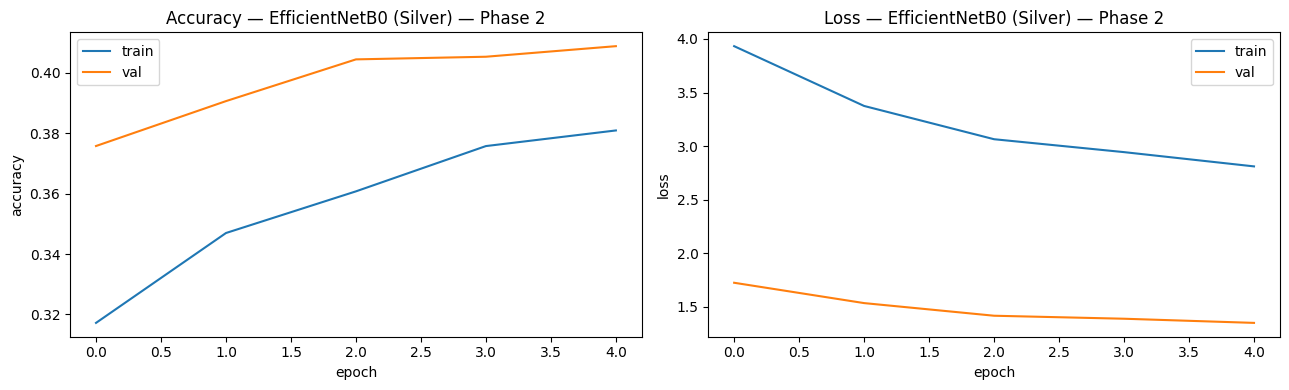

In [47]:
# Phase 2: Unfreeze full backbone — fine-tune end-to-end at very low LR
# LR must be very small (1e-5) — protects pretrained ImageNet weights from
# being destroyed by gradient updates. Same rationale as bronze + homework1.

base_eff.trainable = True
eff_model.compile(optimizer=Adam(learning_rate=1e-5),
    loss=focal_loss_fn,
    metrics=['accuracy'])

print('=== EfficientNetB0 — Phase 2: Full Fine-Tuning (lr=1e-5) ===')
print(f'Trainable params now: {sum(v.numpy().size for v in eff_model.trainable_variables):,}')

eff_history = eff_model.fit(train_gen,
    epochs=20,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=callbacks_eff)

plot_learning_curve(eff_history, title='EfficientNetB0 (Silver) — Phase 2')


179/179 ━━━━━━━━━━━━━━━━━━━━ 118s 623ms/step

=== EfficientNetB0 (Silver) — Classification Report ===
              precision    recall  f1-score   support

         mel     0.4705    0.4860    0.4781       821
          nv     0.7766    0.7737    0.7751      2192
         bcc     0.8387    0.0188    0.0368      1382
         scc     0.1129    0.9019    0.2008       265
       akiec     0.5000    0.0458    0.0840       240
         bkl     0.5000    0.0034    0.0067       592
          df     0.1905    0.1569    0.1720        51
        vasc     0.3947    0.5769    0.4688        52
         unk     0.0888    0.2869    0.1357       122

    accuracy                         0.4278      5717
   macro avg     0.4303    0.3611    0.2620      5717
weighted avg     0.6532    0.4278    0.3970      5717

  Balanced accuracy (macro-avg recall): 0.3611

=== EfficientNetB0 (Silver) — AUROC ===
  Class       AUROC
  ------------------
  mel        0.8181
  nv         0.9116
  bcc        0.8823
  sc

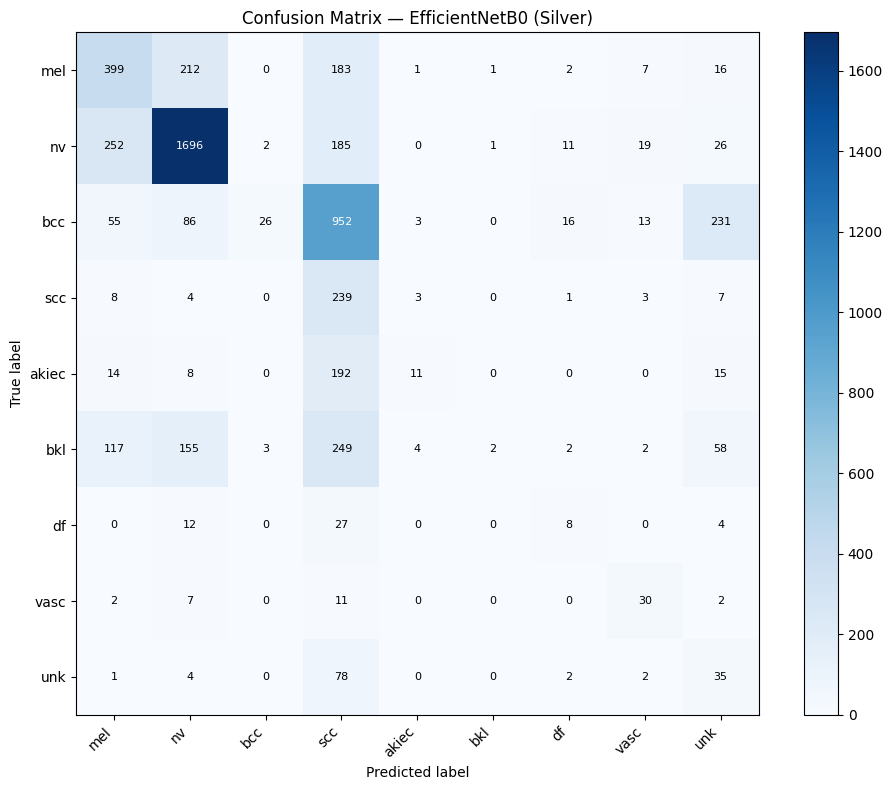

In [48]:
# ── Evaluate EfficientNetB0 on held-out test set ─────────────────────────────
best_eff = tf.keras.models.load_model('/content/drive/MyDrive/SILVER FOLDER/checkpoints/effnet_silver_best.keras',
    custom_objects={'FocalLoss': FocalLoss})

# Probabilities from TF model — remap generator indices to canonical order
y_prob_eff_raw = best_eff.predict(test_gen)
y_prob_eff     = np.zeros_like(y_prob_eff_raw)
for gen_idx, canon_idx in gen_to_canon.items():
    y_prob_eff[:, canon_idx] = y_prob_eff_raw[:, gen_idx]

y_true_eff  = np.array([gen_to_canon[i] for i in test_gen.classes])
y_pred_eff  = y_prob_eff.argmax(axis=1)

eff_bal_acc, eff_macro_auc = evaluate_predictions(y_true_eff, y_pred_eff, y_prob_eff, LABEL_NAMES, 'EfficientNetB0 (Silver)')


## 8. Model 2 - SwinV2 (Vision Transformer)

**Why SwinV2?**

EfficientNetB0 uses convolutional layers - each filter looks at a small local neighbourhood
(3×3 or 5×5 pixels). This is great for detecting edges and textures, but lesion malignancy
often depends on **global context**: irregular border at one corner, atypical colour at another,
asymmetric overall structure. A convolutional kernel at position (50, 50) cannot directly
attend to what is happening at (180, 180).

**SwinV2** (Shifted Window Transformer v2) uses **self-attention** - every patch in the image
can attend to every other patch, capturing the long-range spatial dependencies that CNN
convolutions cannot. SwinV2 extends the original Swin Transformer with:
- Log-spaced continuous relative position bias - transfers better from smaller to larger resolution
- Scaled cosine attention - more stable for fine-tuning

We use **SwinV2-tiny** (pre-trained on ImageNet-22k) from the `timm` library.
Input resolution: **256×256** (SwinV2-tiny's native window size).


In [49]:
# SwinV2-tiny — load pretrained, freeze backbone, replace head

swin_model = timm.create_model('swinv2_tiny_window8_256',   # tiny = ~28M params, good T4 fit
    pretrained=True,
    num_classes=0,               # remove ImageNet head — we add our own
    global_pool='avg')

embed_dim = swin_model.num_features  # 768 for swinv2_tiny

# Freeze all backbone parameters — Phase 1
for p in swin_model.parameters():
    p.requires_grad = False

# Custom classification head
swin_head = nn.Sequential(
    nn.Linear(embed_dim, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, N_CLASSES)
).to(DEVICE)

# Wrap backbone + head into one module
class SwinClassifier(nn.Module):
    def __init__(self, backbone, head):
        super().__init__()
        self.backbone = backbone
        self.head     = head

    def forward(self, x):
        features = self.backbone(x)   # shape: [batch, embed_dim]
        return self.head(features)

swin_classifier = SwinClassifier(swin_model, swin_head).to(DEVICE)

trainable = sum(p.numel() for p in swin_classifier.parameters() if p.requires_grad)
total     = sum(p.numel() for p in swin_classifier.parameters())
print(f'SwinV2-tiny total params : {total:,}')
print(f'Trainable (head only)    : {trainable:,}')


model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

SwinV2-tiny total params : 28,105,523
Trainable (head only)    : 527,369


=== SwinV2 — Phase 1: Head Training (backbone frozen) ===
  Epoch  1/8 — train_loss=1.7403  val_loss=1.5227  val_acc=0.4228  saved ✓
  Epoch  2/8 — train_loss=1.5721  val_loss=1.4552  val_acc=0.4559  saved ✓
  Epoch  3/8 — train_loss=1.4926  val_loss=1.3994  val_acc=0.5285  saved ✓
  Epoch  4/8 — train_loss=1.4217  val_loss=1.3623  val_acc=0.5224  saved ✓
  Epoch  5/8 — train_loss=1.3645  val_loss=1.2809  val_acc=0.5570  saved ✓
  Epoch  6/8 — train_loss=1.3320  val_loss=1.2696  val_acc=0.5605  saved ✓
  Epoch  7/8 — train_loss=1.2765  val_loss=1.2661  val_acc=0.5698  saved ✓
  Epoch  8/8 — train_loss=1.2599  val_loss=1.2547  val_acc=0.5682  saved ✓

=== SwinV2 — Phase 2: Full Fine-Tuning (lr=1e-5) ===
  Epoch  1/15 — train_loss=1.2377  val_loss=1.1150  val_acc=0.6237  saved ✓
  Epoch  2/15 — train_loss=1.1048  val_loss=1.0369  val_acc=0.6403  saved ✓
  Epoch  3/15 — train_loss=1.0402  val_loss=1.0071  val_acc=0.6470  saved ✓
  Epoch  4/15 — train_loss=0.9728  val_loss=0.9491  val_acc=

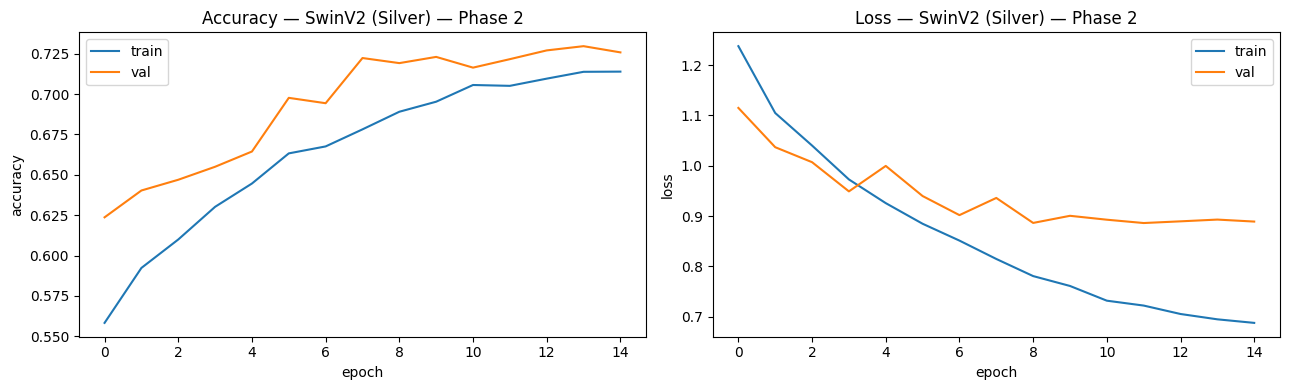

In [50]:
# SwinV2 Phase 1: Head only (backbone frozen, 8 epochs)
SWIN_SAVE = '/content/drive/MyDrive/SILVER FOLDER/checkpoints/swinv2_silver_best.pt'

print('=== SwinV2 — Phase 1: Head Training (backbone frozen) ===')
swin_p1_history = train_pytorch_model(
    swin_classifier, train_loader_swin, val_loader_swin,
    n_epochs=8, lr=1e-3,
    class_weights_tensor=class_weight_torch,
    save_path=SWIN_SAVE,
    model_name='SwinV2-Phase1',
    freeze_backbone=True,
    unfreeze_at=None
)

# SwinV2 Phase 2: Unfreeze backbone — full fine-tune at 1e-5
for p in swin_classifier.backbone.parameters():
    p.requires_grad = True

print('\n=== SwinV2 — Phase 2: Full Fine-Tuning (lr=1e-5) ===')
swin_history = train_pytorch_model(
    swin_classifier, train_loader_swin, val_loader_swin,
    n_epochs=15, lr=1e-5,
    class_weights_tensor=class_weight_torch,
    save_path=SWIN_SAVE,
    model_name='SwinV2-Phase2'
)

plot_learning_curve(swin_history, title='SwinV2 (Silver) — Phase 2')



=== SwinV2 (Silver) — Classification Report ===
              precision    recall  f1-score   support

         mel     0.5448    0.7479    0.6304       821
          nv     0.9045    0.7473    0.8184      2192
         bcc     0.8068    0.7706    0.7883      1382
         scc     0.5137    0.5660    0.5386       265
       akiec     0.5664    0.6750    0.6160       240
         bkl     0.6637    0.5068    0.5747       592
          df     0.4625    0.7255    0.5649        51
        vasc     0.5541    0.7885    0.6508        52
         unk     0.2836    0.6393    0.3929       122

    accuracy                         0.7145      5717
   macro avg     0.5889    0.6852    0.6194      5717
weighted avg     0.7516    0.7145    0.7246      5717

  Balanced accuracy (macro-avg recall): 0.6852

=== SwinV2 (Silver) — AUROC ===
  Class       AUROC
  ------------------
  mel        0.9185
  nv         0.9575
  bcc        0.9643
  scc        0.9441
  akiec      0.9760
  bkl        0.9043
  df 

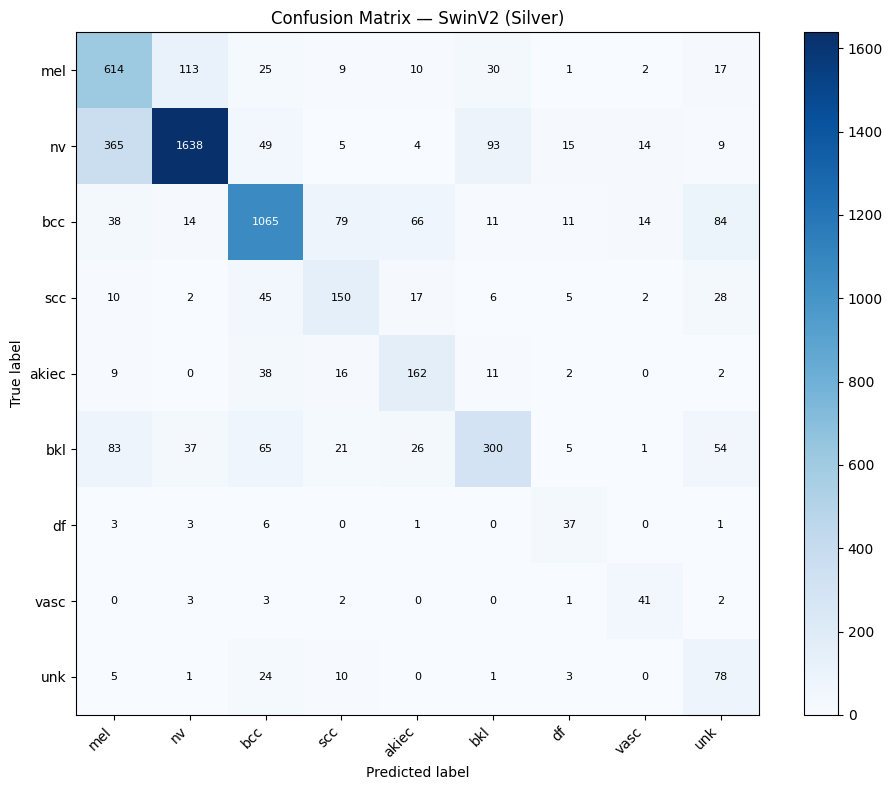

In [51]:
# Evaluate SwinV2 on held-out test set
y_true_swin, y_pred_swin, y_prob_swin = get_pytorch_probs(
    swin_classifier, test_loader_swin, save_path=SWIN_SAVE)

swin_bal_acc, swin_macro_auc = evaluate_predictions(
    y_true_swin, y_pred_swin, y_prob_swin, LABEL_NAMES, 'SwinV2 (Silver)')


## 9. Model 3 - BiomedCLIP

**Why BiomedCLIP?**

Both EfficientNetB0 and SwinV2 are pre-trained on ImageNet - a dataset of everyday photographs
(cats, cars, furniture). They learn excellent low-level features (edges, textures, shapes),
but they have never seen a histology slide, a dermoscope image, or a clinical photo during
pre-training. Every fine-tuning epoch must fight against an ImageNet prior that has nothing
to do with skin lesions.

**BiomedCLIP** (Microsoft) is pre-trained on **15 million** biomedical image–text pairs from
PubMed Central - histology slides, X-rays, dermoscopic images, microscopy. Its visual encoder
already understands the visual language of medicine before we show it a single training image.

We use the vision encoder of BiomedCLIP and attach a lightweight classification head.
The CLIP contrastive pre-training also means the feature space is semantically rich -
features that distinguish "melanoma" from "benign nevus" in medical literature are likely
already partially encoded in the feature vectors.

Architecture: **ViT-B/16 vision encoder** (from BiomedCLIP) + 2-layer MLP head.
Input: **224×224** (BiomedCLIP's native resolution).


In [53]:
# BiomedCLIP - load vision encoder from HuggingFace hub
# Model card: microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224

clip_model, clip_train_transform, clip_val_transform = open_clip.create_model_and_transforms(
    'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
)
clip_model = clip_model.to(DEVICE)

# We only use the visual tower — discard the text encoder
vision_encoder = clip_model.visual

# Dynamically determine the embedding dimension using a dummy forward pass
# (Timm-wrapped models in open_clip don't always expose 'output_dim')
with torch.no_grad():
    dummy_img = torch.randn(1, 3, 224, 224).to(DEVICE)
    embed_dim_clip = vision_encoder(dummy_img).shape[1]

print(f'BiomedCLIP vision encoder output dim: {embed_dim_clip}')

class BiomedCLIPClassifier(nn.Module):
    """
    Wraps BiomedCLIP vision encoder with a classification head.
    Phase 1: backbone frozen, head trains.
    Phase 2: unfreeze encoder, fine-tune end-to-end at low LR.
    """
    def __init__(self, encoder, embed_dim, n_classes):
        super().__init__()
        self.encoder = encoder
        self.head    = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 512),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes)
        )

    def forward(self, x):
        features = self.encoder(x)
        return self.head(features)

biomedclip_model = BiomedCLIPClassifier(vision_encoder, embed_dim_clip, N_CLASSES).to(DEVICE)

# Freeze encoder for Phase 1
for p in biomedclip_model.encoder.parameters():
    p.requires_grad = False

total_clip   = sum(p.numel() for p in biomedclip_model.parameters())
train_clip   = sum(p.numel() for p in biomedclip_model.parameters() if p.requires_grad)
print(f'BiomedCLIP total params     : {total_clip:,}')
print(f'Trainable (head only, Ph 1) : {train_clip:,}')

BiomedCLIP vision encoder output dim: 512
BiomedCLIP total params     : 86,589,193
Trainable (head only, Ph 1) : 397,321


In [54]:
# BiomedCLIP uses its own preprocessing pipeline
# clip_train_transform from open_clip applies the correct mean/std for BiomedCLIP
# We wrap it with our augmentation for training

biomedclip_train_tf = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(30),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    clip_train_transform.transforms[-1]   # BiomedCLIP normalisation (last step only)
    if hasattr(clip_train_transform, 'transforms') else clip_train_transform
])

# For simplicity: use clip_val_transform for val/test (includes correct normalisation)
train_ds_clip = SkinDataset(train_meta, clip_train_transform)
val_ds_clip   = SkinDataset(val_meta,   clip_val_transform)
test_ds_clip  = SkinDataset(test_meta,  clip_val_transform)

train_loader_clip = DataLoader(train_ds_clip, batch_size=BATCH_PT, shuffle=True,
                                num_workers=2, pin_memory=True)
val_loader_clip   = DataLoader(val_ds_clip,   batch_size=BATCH_PT, shuffle=False,
                                num_workers=2, pin_memory=True)
test_loader_clip  = DataLoader(test_ds_clip,  batch_size=BATCH_PT, shuffle=False,
                                num_workers=2, pin_memory=True)

print(f'BiomedCLIP DataLoaders — train={len(train_ds_clip):,} val={len(val_ds_clip):,}')


BiomedCLIP DataLoaders — train=26,676 val=5,716


=== BiomedCLIP — Phase 1: Head Training (encoder frozen) ===
  Epoch  1/8 — train_loss=1.6517  val_loss=1.4018  val_acc=0.4794  saved ✓
  Epoch  2/8 — train_loss=1.4688  val_loss=1.3714  val_acc=0.5709  saved ✓
  Epoch  3/8 — train_loss=1.3706  val_loss=1.3184  val_acc=0.5381  saved ✓
  Epoch  4/8 — train_loss=1.2886  val_loss=1.2665  val_acc=0.5255  saved ✓
  Epoch  5/8 — train_loss=1.2304  val_loss=1.2373  val_acc=0.5920  saved ✓
  Epoch  6/8 — train_loss=1.1581  val_loss=1.2255  val_acc=0.6090  saved ✓
  Epoch  7/8 — train_loss=1.1080  val_loss=1.2289  val_acc=0.5831  
  Epoch  8/8 — train_loss=1.0698  val_loss=1.2105  val_acc=0.5758  saved ✓

BiomedCLIP trainable params (Phase 2): 86,589,193

=== BiomedCLIP — Phase 2: Full Fine-Tuning (lr=5e-6) ===
  Epoch  1/15 — train_loss=1.0886  val_loss=1.1488  val_acc=0.5924  saved ✓
  Epoch  2/15 — train_loss=0.9260  val_loss=1.1268  val_acc=0.6207  saved ✓
  Epoch  3/15 — train_loss=0.8074  val_loss=1.1116  val_acc=0.6652  saved ✓
  Epoch  

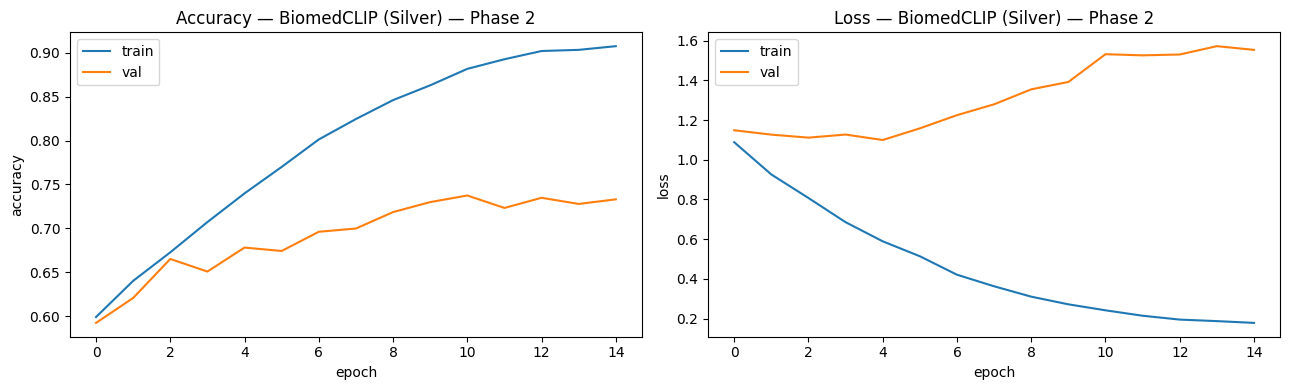

In [55]:
CLIP_SAVE = '/content/drive/MyDrive/SILVER FOLDER/checkpoints/biomedclip_silver_best.pt'

# Phase 1: head only
print('=== BiomedCLIP — Phase 1: Head Training (encoder frozen) ===')
clip_p1_history = train_pytorch_model(
    biomedclip_model, train_loader_clip, val_loader_clip,
    n_epochs=8, lr=1e-3,
    class_weights_tensor=class_weight_torch,
    save_path=CLIP_SAVE,
    model_name='BiomedCLIP-Phase1'
)

# Phase 2: unfreeze encoder
for p in biomedclip_model.encoder.parameters():
    p.requires_grad = True
print(f'\nBiomedCLIP trainable params (Phase 2): '
      f'{sum(p.numel() for p in biomedclip_model.parameters() if p.requires_grad):,}')

print('\n=== BiomedCLIP — Phase 2: Full Fine-Tuning (lr=5e-6) ===')
clip_history = train_pytorch_model(
    biomedclip_model, train_loader_clip, val_loader_clip,
    n_epochs=15, lr=5e-6,   # slightly lower LR — biomedical domain weights are precious
    class_weights_tensor=class_weight_torch,
    save_path=CLIP_SAVE,
    model_name='BiomedCLIP-Phase2'
)

plot_learning_curve(clip_history, title='BiomedCLIP (Silver) — Phase 2')



=== BiomedCLIP (Silver) — Classification Report ===
              precision    recall  f1-score   support

         mel     0.4873    0.7954    0.6043       821
          nv     0.8938    0.6870    0.7769      2192
         bcc     0.7945    0.7301    0.7609      1382
         scc     0.5673    0.4453    0.4989       265
       akiec     0.5296    0.7083    0.6061       240
         bkl     0.5734    0.4814    0.5234       592
          df     0.4286    0.6471    0.5156        51
        vasc     0.5968    0.7115    0.6491        52
         unk     0.2179    0.4590    0.2955       122

    accuracy                         0.6764      5717
   macro avg     0.5655    0.6295    0.5812      5717
weighted avg     0.7265    0.6764    0.6882      5717

  Balanced accuracy (macro-avg recall): 0.6295

=== BiomedCLIP (Silver) — AUROC ===
  Class       AUROC
  ------------------
  mel        0.9132
  nv         0.9471
  bcc        0.9548
  scc        0.9325
  akiec      0.9658
  bkl        0.87

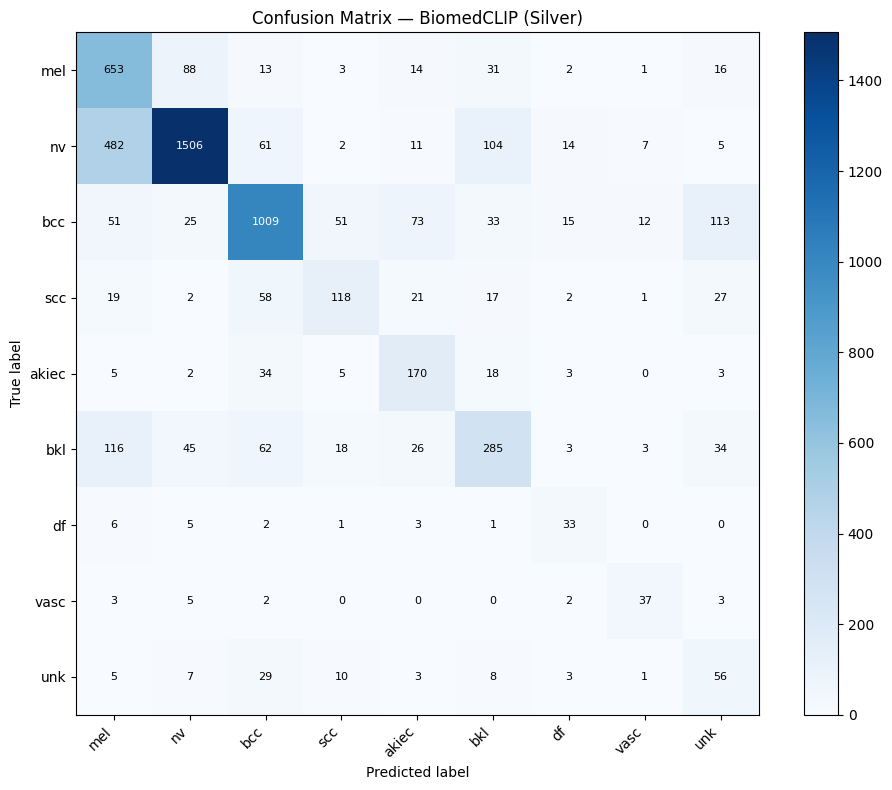

In [56]:
# Evaluate BiomedCLIP on held-out test set
y_true_clip, y_pred_clip, y_prob_clip = get_pytorch_probs(
    biomedclip_model, test_loader_clip, save_path=CLIP_SAVE)

clip_bal_acc, clip_macro_auc = evaluate_predictions(
    y_true_clip, y_pred_clip, y_prob_clip, LABEL_NAMES, 'BiomedCLIP (Silver)')


## 10. Ensemble - Combining the Best Performers

An ensemble averages the **softmax probability vectors** from all three models before
taking the argmax. Because each model has different failure modes:

- **EfficientNetB0** is strong on texture (dermoscopic detail)
- **SwinV2** captures long-range spatial structure (global lesion asymmetry)
- **BiomedCLIP** brings biomedical domain knowledge (pre-trained on medical literature)

…the ensemble tends to be more confident where all three agree (true positives) and
less confident where they disagree (ambiguous cases - where clinical referral is warranted anyway).

This is analogous to the Random Forest idea discussed in class: averaging diverse learners
reduces variance and consistently outperforms any individual model.

> **Note**: y_true arrays from all three models must be aligned to the same test set row order.
> We use `shuffle=False` in all test DataLoaders to guarantee this.



=== Ensemble (EfficientNetB0 + SwinV2 + BiomedCLIP) — Classification Report ===
              precision    recall  f1-score   support

         mel     0.5463    0.7978    0.6485       821
          nv     0.9003    0.7664    0.8280      2192
         bcc     0.8524    0.7395    0.7919      1382
         scc     0.4692    0.6906    0.5588       265
       akiec     0.6269    0.6792    0.6520       240
         bkl     0.7066    0.4679    0.5630       592
          df     0.5522    0.7255    0.6271        51
        vasc     0.6000    0.8077    0.6885        52
         unk     0.2737    0.6148    0.3788       122

    accuracy                         0.7231      5717
   macro avg     0.6142    0.6988    0.6374      5717
weighted avg     0.7672    0.7231    0.7336      5717

  Balanced accuracy (macro-avg recall): 0.6988

=== Ensemble (EfficientNetB0 + SwinV2 + BiomedCLIP) — AUROC ===
  Class       AUROC
  ------------------
  mel        0.9200
  nv         0.9564
  bcc        0.9672
 

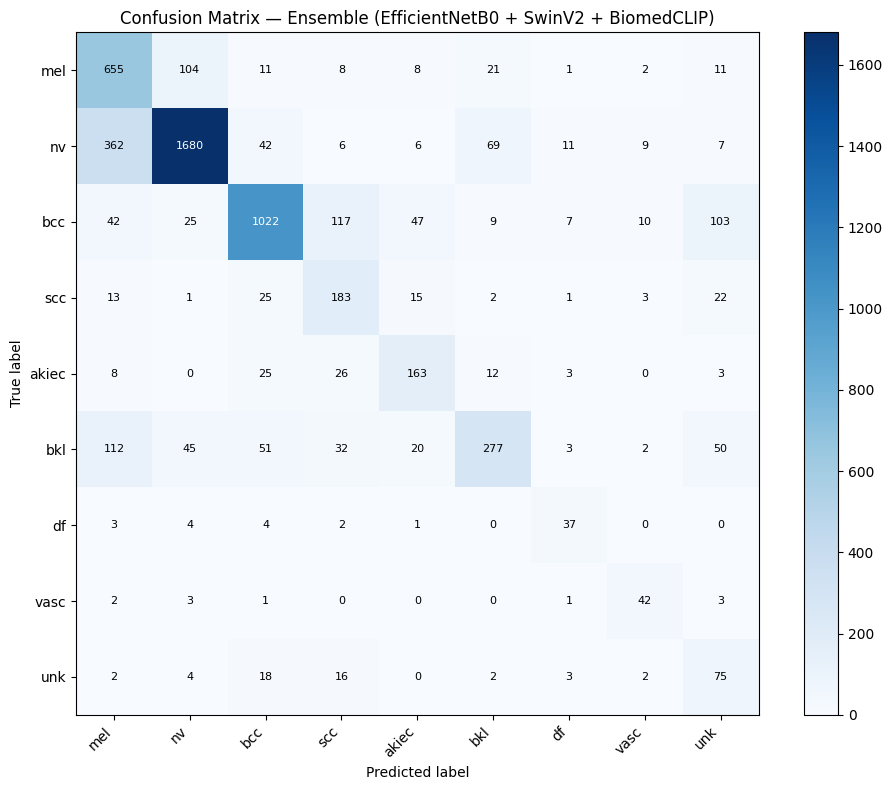

In [57]:
# Verify test set alignment
assert np.array_equal(y_true_swin, y_true_clip), \
    'y_true mismatch between SwinV2 and BiomedCLIP — check shuffle=False in DataLoaders'
assert len(y_true_eff) == len(y_true_swin), \
    'Test set size mismatch between TF and PyTorch — check test DataFrame ordering'

# If TF test set is in alphabetical generator order, remap to canonical before ensembling
# (already done when we computed y_true_eff above)
y_true_ensemble = y_true_swin  # canonical order, confirmed equal to y_true_clip

# Average softmax probabilities — equal weight ensemble
ensemble_probs = (y_prob_eff + y_prob_swin + y_prob_clip) / 3.0
y_pred_ensemble = ensemble_probs.argmax(axis=1)

ensemble_bal_acc, ensemble_macro_auc = evaluate_predictions(
    y_true_ensemble, y_pred_ensemble, ensemble_probs, LABEL_NAMES,
    'Ensemble (EfficientNetB0 + SwinV2 + BiomedCLIP)')


## 11. Grad-CAM - Explainability (XAI)

Neural networks in clinical settings must be **interpretable**. A radiologist or dermatologist
cannot act on a black-box prediction — they need to understand *which region of the lesion*
drove the classification decision. Grad-CAM generates a heatmap that overlays on the original
image, highlighting the pixels with the strongest gradient signal relative to the predicted class.

**Why this matters for healthcare AI:**
- If the model highlights the lesion border → likely detecting irregular borders (clinical sign)
- If the model highlights background dermoscope artefact → the model is cheating, not diagnosing
- Regulators and clinicians increasingly require this level of transparency before deployment

We implement Grad-CAM for EfficientNetB0 (TF) using the gradient tape approach,
and for SwinV2/BiomedCLIP (PyTorch) using the `grad-cam` library.


In [68]:
# Grad-CAM for EfficientNetB0 (TensorFlow)

def get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    """
    Compute Grad-CAM heatmap for a single image (batch of 1).
    img_array: preprocessed numpy array of shape (1, H, W, 3)
    Returns: heatmap as 2D numpy array (values 0–1)
    """
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads     = tape.gradient(class_channel, conv_output)
    pooled    = tf.reduce_mean(grads, axis=(0, 1, 2))   # global average pooling over spatial dims
    conv_out  = conv_output[0]
    heatmap   = conv_out @ pooled[..., tf.newaxis]
    heatmap   = tf.squeeze(heatmap).numpy()
    heatmap   = np.maximum(heatmap, 0) / (heatmap.max() + 1e-8)
    return heatmap


def overlay_gradcam(img_path, heatmap, alpha=0.4, colormap=mpl_cm.jet):
    """Resize heatmap to image size and overlay — returns overlay as numpy RGB array."""
    img = np.array(Image.open(img_path).convert('RGB').resize((224, 224)))
    heatmap_resized = np.uint8(255 * heatmap)
    heatmap_resized = Image.fromarray(heatmap_resized).resize((224, 224))
    heatmap_colored = colormap(np.array(heatmap_resized) / 255.0)[:, :, :3]
    overlay = (1 - alpha) * img / 255.0 + alpha * heatmap_colored
    overlay = np.clip(overlay, 0, 1)
    return overlay


def show_gradcam_grid(model, df_subset, last_conv_layer, n=6):
    """Display Grad-CAM overlays for n random images from df_subset."""
    sample = df_subset.sample(n, random_state=42)
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))

    for col, (_, row) in enumerate(sample.iterrows()):
        # Original image
        img = Image.open(row['path']).convert('RGB').resize((224, 224))
        axes[0, col].imshow(img)
        axes[0, col].set_title(f'True: {row["label"]}\nPred: {LABEL_NAMES[y_pred_eff[col]]}',
                                fontsize=8)
        axes[0, col].axis('off')

        # Grad-CAM overlay
        img_arr = eff_preprocess(np.expand_dims(np.array(img), 0).astype('float32'))
        heatmap  = get_gradcam_heatmap(model, img_arr, last_conv_layer)
        overlay  = overlay_gradcam(row['path'], heatmap)
        axes[1, col].imshow(overlay)
        axes[1, col].set_title('Grad-CAM', fontsize=8)
        axes[1, col].axis('off')

    plt.suptitle('Grad-CAM - EfficientNetB0 (Silver)', fontsize=27, fontweight='bold')
    plt.tight_layout()
    plt.show()


# EfficientNetB0's last convolutional layer name (confirmed for EfficientNetB0)
EFF_LAST_CONV = 'top_conv'
print(f'Last conv layer for Grad-CAM: {EFF_LAST_CONV}')
print('Run show_gradcam_grid(best_eff, test_meta, EFF_LAST_CONV) after training completes.')


Last conv layer for Grad-CAM: top_conv
Run show_gradcam_grid(best_eff, test_meta, EFF_LAST_CONV) after training completes.


In [69]:
# Grad-CAM for SwinV2 / BiomedCLIP (PyTorch — pytorch-grad-cam library)
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

def show_gradcam_pytorch(model, loader, target_layers, model_name, n=6, reshape_transform=None):
    """
    Display Grad-CAM for n samples using pytorch-grad-cam.
    target_layers: list of torch.nn.Module — e.g. [model.backbone.layers[-1].blocks[-1].norm1]
    """
    cam = GradCAM(model=model, target_layers=target_layers, reshape_transform=reshape_transform)

    imgs_shown, labels_shown = 0, []
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))

    for imgs, lbls in loader:
        for i in range(imgs.size(0)):
            if imgs_shown >= n:
                break
            img_tensor = imgs[i:i+1].to(DEVICE)
            grayscale_cam = cam(input_tensor=img_tensor)[0]

            # Inverse-normalise for display
            mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
            std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
            img_disp = (imgs[i] * std + mean).permute(1, 2, 0).clamp(0, 1).numpy()

            overlay = show_cam_on_image(img_disp, grayscale_cam, use_rgb=True)

            axes[0, imgs_shown].imshow(img_disp)
            axes[0, imgs_shown].set_title(f'True: {LABEL_NAMES[lbls[i]]}', fontsize=8)
            axes[0, imgs_shown].axis('off')
            axes[1, imgs_shown].imshow(overlay)
            axes[1, imgs_shown].set_title('Grad-CAM', fontsize=8)
            axes[1, imgs_shown].axis('off')
            imgs_shown += 1
        if imgs_shown >= n:
            break

    plt.suptitle(f'Grad-CAM - {model_name}', fontsize=27, fontweight='bold')
    plt.tight_layout()
    plt.show()


# SwinV2 target layer — last transformer block's norm layer
# Adjust layer path if you use a different SwinV2 variant
swin_target_layers = [swin_classifier.backbone.layers[-1].blocks[-1].norm1]
print('SwinV2 Grad-CAM target layer configured.')
print('Run: show_gradcam_pytorch(swin_classifier, test_loader_swin, swin_target_layers, "SwinV2")')


SwinV2 Grad-CAM target layer configured.
Run: show_gradcam_pytorch(swin_classifier, test_loader_swin, swin_target_layers, "SwinV2")


In [70]:
# Run Grad-CAM visualisations (run after training is complete)

# EfficientNetB0
show_gradcam_grid(best_eff, test_meta, EFF_LAST_CONV, n=6)

# SwinV2
show_gradcam_pytorch(swin_classifier, test_loader_swin,
                     swin_target_layers, 'SwinV2', n=6)

# BiomedCLIP - ViT final attention block
try:
    # Standard open_clip structure
    clip_target_layers = [biomedclip_model.encoder.transformer.resblocks[-1].ln_1]
except AttributeError:
    try:
        # timm-wrapped structure directly
        clip_target_layers = [biomedclip_model.encoder.blocks[-1].norm1]
    except AttributeError:
        # timm-wrapped structure inside 'trunk' (open_clip TimmModel)
        clip_target_layers = [biomedclip_model.encoder.trunk.blocks[-1].norm1]

def vit_reshape_transform(tensor, height=14, width=14):
    # Remove class token and reshape the spatial tokens back into a 2D grid
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    # Rearrange channels: [B, H, W, C] -> [B, C, H, W]
    result = result.transpose(2, 3).transpose(1, 2)
    return result

show_gradcam_pytorch(biomedclip_model, test_loader_clip,
                     clip_target_layers, 'BiomedCLIP', n=6,
                     reshape_transform=vit_reshape_transform)


Output hidden; open in https://colab.research.google.com to view.

## 12. Held-out Fairness Audit - Fitzpatrick17k & DDI

**These datasets were never used during training.** They exist solely to stress-test whether
the model's performance degrades on under-represented skin tones.

### Why does this matter clinically?
A model with 88% macro accuracy on the test set might achieve 93% on Fitzpatrick I–II
(light skin) and only 72% on Fitzpatrick V–VI (dark skin). Reporting one number hides this gap.
The communities with the least access to specialist dermatology care are often the same
communities whose skin tones are least represented in training data.

### Datasets
- **Fitzpatrick17k**: 16,577 images annotated with Fitzpatrick skin type I–VI + disease labels.
  We use this as the **primary equity benchmark** - report per-Fitzpatrick accuracy and mel recall.
- **DDI (Diverse Dermatology Images, Stanford)**: 656 images, balanced across Fitzpatrick I–VI,
  includes pathology-confirmed diagnoses. Smaller but carefully curated for bias stress-testing.

### Key metrics reported
| Metric | Why |
|---|---|
| Accuracy per Fitzpatrick type | Overall performance fairness |
| Mel recall per Fitzpatrick type | High-risk miss rate per skin tone |
| Max accuracy gap | Single number capturing worst-case disparity |
| Max mel-recall gap | Clinical consequence of disparate melanoma detection |


In [84]:
import os
import pandas as pd
import urllib.request
import urllib.parse
import kagglehub

print("Downloading alternate Fitzpatrick17k dataset...")
fitz_path = kagglehub.dataset_download("nazmusresan/fitzpatrick17k")

print("Kaggle dataset missing CSV. Downloading metadata directly from the official GitHub repo...")
csv_url = "https://raw.githubusercontent.com/mattgroh/fitzpatrick17k/master/fitzpatrick17k.csv"

try:
    fitz17k_meta = pd.read_csv(csv_url)
    print(f"Successfully loaded metadata from GitHub! ({len(fitz17k_meta)} rows)")
except Exception as e:
    print(f"Could not download from GitHub: {e}")
    print("Please upload fitzpatrick17k.csv manually to the Colab files pane.")
    if os.path.exists("fitzpatrick17k.csv"):
        fitz17k_meta = pd.read_csv("fitzpatrick17k.csv")
        print("Loaded local fitzpatrick17k.csv")

if 'fitz17k_meta' in locals():
    downloaded_images = []
    for root_dir, _, files in os.walk(fitz_path):
        for f in files:
            if f.endswith(('.jpg', '.png', '.jpeg')):
                downloaded_images.append(os.path.join(root_dir, f))

    print(f"Total downloaded images found in Kaggle folder: {len(downloaded_images)}")

    # Create quick lookups from the CSV for O(1) matching
    md5_to_row = {str(row['md5hash']).lower(): row.to_dict()
                  for _, row in fitz17k_meta.iterrows() if pd.notna(row['md5hash'])}

    url_to_row = {}
    for _, row in fitz17k_meta.iterrows():
        if pd.notna(row['url']):
            f_url = row['url'].split('/')[-1].split('?')[0].split('#')[0].lower()
            url_to_row[f_url] = row.to_dict()
            url_to_row[urllib.parse.unquote(f_url)] = row.to_dict()

    FITZ17K_LABEL_MAP = {
        'melanoma': 'mel', 'basal cell carcinoma': 'bcc', 'squamous cell carcinoma': 'scc',
        'actinic keratosis': 'akiec', 'seborrheic keratosis': 'bkl', 'dermatofibroma': 'df',
        'vascular lesion': 'vasc', 'melanocytic nevi': 'nv', 'nevus': 'nv',
    }

    matched_data = []
    for path in downloaded_images:
        fname = os.path.basename(path).lower()
        fname_no_ext = os.path.splitext(fname)[0]

        # Match against md5hash first, then URL filename
        if fname_no_ext in md5_to_row:
            row_data = md5_to_row[fname_no_ext]
        elif fname in url_to_row:
            row_data = url_to_row[fname]
        else:
            continue

        row_data['path'] = path
        matched_data.append(row_data)

    fitz17k_df = pd.DataFrame(matched_data)

    if not fitz17k_df.empty:
        # The original CSV has the specific disease in the 'label' column
        if 'label' in fitz17k_df.columns:
            fitz17k_df['original_disease'] = fitz17k_df['label']
            fitz17k_df['label'] = fitz17k_df['original_disease'].str.lower().map(FITZ17K_LABEL_MAP).fillna('unk')
        else:
            fitz17k_df['label'] = 'unk'

        fitz17k_df['label_idx'] = fitz17k_df['label'].map(LABEL2IDX).fillna(LABEL2IDX['unk']).astype(int)

        # Replace the global fitz17k_meta with our successfully matched subset
        fitz17k_meta = fitz17k_df

        print(f'\nFitzpatrick17k — {len(fitz17k_meta):,} images successfully mapped and loaded')
        if 'fitzpatrick_scale' in fitz17k_meta.columns:
            print(fitz17k_meta['fitzpatrick_scale'].value_counts().sort_index())
        print("\nMapped label distribution:")
        print(fitz17k_meta['label'].value_counts())
    else:
        print("\nFailed to match any images. The Kaggle dataset filenames do not align with the CSV md5hash or URLs.")


Using Colab cache for faster access to the 'fitzpatrick17k' dataset.
Kaggle dataset missing CSV. Downloading metadata directly from the official GitHub repo...
Successfully loaded metadata from GitHub! (16577 rows)
Total downloaded images found in Kaggle folder: 16574

Fitzpatrick17k — 16,574 images successfully mapped and loaded
fitzpatrick_scale
-1     562
 1    2947
 2    4808
 3    3308
 4    2781
 5    1533
 6     635
Name: count, dtype: int64

Mapped label distribution:
label
unk      14941
scc        581
bcc        468
mel        261
akiec      175
df          79
bkl         69
Name: count, dtype: int64


In [82]:
# Fairness audit helper

def run_fairness_audit(meta_df, model_name, get_probs_fn,
                       fitzpatrick_col='fitzpatrick_scale'):
    """
    Runs per-Fitzpatrick-type accuracy + mel recall for any model.
    get_probs_fn: callable(df) → (y_true_arr, y_pred_arr, y_prob_arr)
    """
    y_true_all, y_pred_all, _ = get_probs_fn(meta_df)
    results = meta_df.copy().reset_index(drop=True)
    results['y_true'] = y_true_all
    results['y_pred'] = y_pred_all

    mel_idx = LABEL2IDX['mel']
    bcc_idx = LABEL2IDX['bcc']

    print(f'\n=== Fairness Audit — {model_name} ===')
    print(f'  {"Fitz Type":<12} {"N":>6} {"Accuracy":>10} {"Mel Recall":>12} {"BCC Recall":>12}')
    print('  ' + '-' * 56)

    group_accs, group_mel_recalls = [], []

    for ft, grp in results.groupby(fitzpatrick_col):
        n      = len(grp)
        acc    = (grp['y_true'] == grp['y_pred']).mean()
        mel_grp     = grp[grp['y_true'] == mel_idx]
        mel_recall  = (mel_grp['y_pred'] == mel_idx).mean() if len(mel_grp) > 0 else float('nan')
        bcc_grp     = grp[grp['y_true'] == bcc_idx]
        bcc_recall  = (bcc_grp['y_pred'] == bcc_idx).mean() if len(bcc_grp) > 0 else float('nan')
        group_accs.append(acc)
        group_mel_recalls.append(mel_recall)
        print(f'  Type {str(ft):<7} {n:>6} {acc:>10.4f} {mel_recall:>12.4f} {bcc_recall:>12.4f}')

    acc_gap     = max(group_accs) - min(group_accs)
    mel_rec_gap = np.nanmax(group_mel_recalls) - np.nanmin(group_mel_recalls)
    print('  ' + '-' * 56)
    print(f'  Max accuracy gap      : {acc_gap:.4f}  (target < 0.05)')
    print(f'  Max mel-recall gap    : {mel_rec_gap:.4f}  (target < 0.10)')
    flag_acc = 'PASS ✓' if acc_gap < 0.05 else 'FAIL — review augmentation & data balance'
    flag_mel = 'PASS ✓' if mel_rec_gap < 0.10 else 'FAIL — darker skin tones missing melanoma'
    print(f'  Accuracy equity       : {flag_acc}')
    print(f'  Mel-recall equity     : {flag_mel}')
    return acc_gap, mel_rec_gap

print('Fairness audit helper ready.')


Fairness audit helper ready.


In [85]:
# Run fairness audit on Fitzpatrick17k for all models

# Helper wrappers that return (y_true, y_pred, y_prob) for any df
def eff_predict_df(df):
    gen = val_test_datagen.flow_from_dataframe(
        df, x_col='path', y_col='label',
        target_size=(224, 224), batch_size=BATCH_SIZE,
        class_mode='categorical', shuffle=False)
    y_prob_raw = best_eff.predict(gen)
    # Remap generator indices → canonical
    y_prob = np.zeros_like(y_prob_raw)
    for gen_i, can_i in gen_to_canon.items():
        y_prob[:, can_i] = y_prob_raw[:, gen_i]
    y_true = np.array([gen_to_canon[i] for i in gen.classes])
    y_pred = y_prob.argmax(1)
    return y_true, y_pred, y_prob

def swin_predict_df(df):
    ds     = SkinDataset(df, swin_val_tf)
    loader = DataLoader(ds, batch_size=BATCH_PT, shuffle=False, num_workers=2)
    return get_pytorch_probs(swin_classifier, loader, save_path=None)

def clip_predict_df(df):
    ds     = SkinDataset(df, clip_val_transform)
    loader = DataLoader(ds, batch_size=BATCH_PT, shuffle=False, num_workers=2)
    return get_pytorch_probs(biomedclip_model, loader, save_path=None)

# Run audit on Fitzpatrick17k
print('Running Fitzpatrick17k fairness audit for all three models...')
eff_acc_gap, eff_mel_gap   = run_fairness_audit(fitz17k_meta, 'EfficientNetB0', eff_predict_df)
swin_acc_gap, swin_mel_gap = run_fairness_audit(fitz17k_meta, 'SwinV2',         swin_predict_df)
clip_acc_gap, clip_mel_gap = run_fairness_audit(fitz17k_meta, 'BiomedCLIP',     clip_predict_df)

# Ensemble on Fitzpatrick17k
_, _, ep = eff_predict_df(fitz17k_meta)
_, _, sp = swin_predict_df(fitz17k_meta)
_, _, cp = clip_predict_df(fitz17k_meta)
ens_probs_fitz = (ep + sp + cp) / 3
fitz17k_meta['y_pred_ens'] = ens_probs_fitz.argmax(1)
fitz17k_meta['y_true']     = fitz17k_meta['label_idx']

mel_idx = LABEL2IDX['mel']
ens_acc_gap = 0
ens_mel_gap = 0
print('\n=== Ensemble Fairness (Fitzpatrick17k) — Quick Summary ===')
for ft, grp in fitz17k_meta.groupby('fitzpatrick_scale'):
    acc = (grp['y_true'] == grp['y_pred_ens']).mean()
    mel_r = (grp[grp['y_true']==mel_idx]['y_pred_ens'] == mel_idx).mean() if (grp['y_true']==mel_idx).any() else float('nan')
    print(f'  Type {ft}: acc={acc:.4f}  mel_recall={mel_r:.4f}')


Running Fitzpatrick17k fairness audit for all three models...
Found 16574 validated image filenames belonging to 7 classes.
518/518 ━━━━━━━━━━━━━━━━━━━━ 112s 207ms/step

=== Fairness Audit — EfficientNetB0 ===
  Fitz Type         N   Accuracy   Mel Recall   BCC Recall
  --------------------------------------------------------
  Type -1         562     0.3648       0.0588       0.0000
  Type 1         2947     0.2772       0.0976       0.0000
  Type 2         4808     0.2814       0.1852       0.0000
  Type 3         3308     0.2706       0.1400       0.0000
  Type 4         2781     0.2478       0.1316       0.0000
  Type 5         1533     0.2407       0.0870       0.0000
  Type 6          635     0.3354       0.2727       0.0000
  --------------------------------------------------------
  Max accuracy gap      : 0.1241  (target < 0.05)
  Max mel-recall gap    : 0.2139  (target < 0.10)
  Accuracy equity       : FAIL — review augmentation & data balance
  Mel-recall equity     : FAIL —

In [88]:
# DDI (Stanford) — Diverse Dermatology Images bias stress test
# DDI CSV columns: DDI_file, skin_tone, malignant, disease
# skin_tone: 12, 34, 56 (Fitzpatrick I-II, III-IV, V-VI)
import os
import pandas as pd
import numpy as np
import kagglehub

print("Ensuring DDI dataset is downloaded...")
ddi_path = kagglehub.dataset_download("souvikda/ddidiversedermatology-multimodal-dataset")

# Find the metadata CSV
DDI_META_CSV = None
for root_dir, _, files in os.walk(ddi_path):
    if 'ddi_metadata.csv' in files:
        DDI_META_CSV = os.path.join(root_dir, 'ddi_metadata.csv')
        break

if not DDI_META_CSV:
    raise FileNotFoundError("Could not find ddi_metadata.csv in the downloaded dataset.")

print(f"Loading metadata from: {DDI_META_CSV}")
ddi_meta = pd.read_csv(DDI_META_CSV)

# Find all images
img_path_map = {}
for root_dir, _, files in os.walk(ddi_path):
    for f in files:
        if f.endswith(('.png', '.jpg', '.jpeg', '.PNG', '.JPG')):
            img_path_map[f] = os.path.join(root_dir, f)

DDI_LABEL_MAP = {
    'melanoma': 'mel', 'basal cell carcinoma': 'bcc',
    'squamous cell carcinoma': 'scc', 'actinic keratosis': 'akiec',
    'seborrheic keratosis': 'bkl', 'dermatofibroma': 'df', 'nevus': 'nv',
}

ddi_meta['label'] = ddi_meta['disease'].str.lower().map(DDI_LABEL_MAP).fillna('unk')
# Map the file paths dynamically
ddi_meta['path'] = ddi_meta['DDI_file'].map(img_path_map)
ddi_meta['label_idx'] = ddi_meta['label'].map(LABEL2IDX).fillna(LABEL2IDX['unk']).astype(int)

# Drop rows where image was not found
ddi_meta = ddi_meta.dropna(subset=['path']).reset_index(drop=True)

print(f'DDI — {len(ddi_meta):,} images loaded')
print(ddi_meta['skin_tone'].value_counts())

# Bias stress test: malignant recall per skin tone group
if len(ddi_meta) > 0:
    print('\n=== DDI — Malignant Lesion Recall per Skin Tone (Ensemble) ===')
    _, _, ep_d = eff_predict_df(ddi_meta)
    _, _, sp_d = swin_predict_df(ddi_meta)
    _, _, cp_d = clip_predict_df(ddi_meta)
    ens_probs_ddi = (ep_d + sp_d + cp_d) / 3

    HIGH_RISK_IDXS = {LABEL2IDX['mel'], LABEL2IDX['bcc'], LABEL2IDX['scc']}

    for tone, grp in ddi_meta.groupby('skin_tone'):
        malignant_mask = grp['malignant'].astype(bool)
        if malignant_mask.sum() == 0:
            continue
        idxs = grp.index.tolist()
        preds = ens_probs_ddi[idxs].argmax(1)
        mal_recall = np.mean([p in HIGH_RISK_IDXS for p in preds[malignant_mask.values]])
        print(f'  Skin tone {tone}: malignant recall = {mal_recall:.4f}  (N_malignant={malignant_mask.sum()})')
else:
    print("No DDI images were successfully matched.")


Ensuring DDI dataset is downloaded...
Using Colab cache for faster access to the 'ddidiversedermatology-multimodal-dataset' dataset.
Loading metadata from: /kaggle/input/ddidiversedermatology-multimodal-dataset/ddidiversedermatologyimages/ddi_metadata.csv
DDI — 656 images loaded
skin_tone
34    241
12    208
56    207
Name: count, dtype: int64

=== DDI — Malignant Lesion Recall per Skin Tone (Ensemble) ===
Found 656 validated image filenames belonging to 3 classes.
21/21 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step
  Skin tone 12: malignant recall = 0.4898  (N_malignant=49)
  Skin tone 34: malignant recall = 0.5676  (N_malignant=74)
  Skin tone 56: malignant recall = 0.3542  (N_malignant=48)


## 13. Final Comparison Table

In [89]:
# Final comparison table — all Silver models
# Collect per-model mel recall, bcc recall, balanced acc, macro AUROC, Fitz gap

def get_class_recall(y_true, y_pred, class_idx):
    mask = y_true == class_idx
    if mask.sum() == 0:
        return float('nan')
    return (y_pred[mask] == class_idx).mean()

mel_idx = LABEL2IDX['mel']
bcc_idx = LABEL2IDX['bcc']
scc_idx = LABEL2IDX['scc']

rows = [
    # Bronze reference (fill in from your bronze notebook results)
    ('Bronze — EfficientNetB0 (HAM10000)', '—', '—', '—', '—', '—', '—'),
]

model_results = [
    ('EfficientNetB0 (Silver)',             y_true_eff,      y_pred_eff,      y_prob_eff,      eff_acc_gap),
    ('SwinV2 (Silver)',                     y_true_swin,     y_pred_swin,     y_prob_swin,     swin_acc_gap),
    ('BiomedCLIP (Silver)',                 y_true_clip,     y_pred_clip,     y_prob_clip,     clip_acc_gap),
    ('Ensemble (Eff + Swin + CLIP)',        y_true_ensemble, y_pred_ensemble, ensemble_probs,  None),
]

for name, yt, yp, ypr, fitz_gap in model_results:
    mel_rec  = get_class_recall(yt, yp, mel_idx)
    bcc_rec  = get_class_recall(yt, yp, bcc_idx)
    scc_rec  = get_class_recall(yt, yp, scc_idx)
    bal_acc  = balanced_accuracy_score(yt, yp)
    n        = len(LABEL_NAMES)
    yb       = label_binarize(yt, classes=list(range(n)))
    m_auc    = roc_auc_score(yb, ypr, average='macro')
    fitz_str = f'{fitz_gap:.4f}' if fitz_gap is not None else 'N/A'
    rows.append((name, f'{mel_rec:.4f}', f'{bcc_rec:.4f}', f'{scc_rec:.4f}',
                 f'{bal_acc:.4f}', f'{m_auc:.4f}', fitz_str))

# Print table
hdr = f'  {"Model":<42} {"MEL Rec":>9} {"BCC Rec":>9} {"SCC Rec":>9} {"Bal Acc":>9} {"AUROC":>8} {"Fitz Gap":>10}'
sep = '  ' + '-' * (len(hdr) - 2)
print('=' * len(hdr))
print('  DermaVision AI — Silver Model Performance Comparison')
print('  Primary metric: Recall for high-risk classes (mel, bcc, scc)')
print('  Fairness metric: Max accuracy gap across Fitzpatrick I–VI (target < 0.05)')
print('=' * len(hdr))
print(hdr)
print(sep)
for r in rows:
    print(f'  {r[0]:<42} {r[1]:>9} {r[2]:>9} {r[3]:>9} {r[4]:>9} {r[5]:>8} {r[6]:>10}')
print('=' * len(hdr))
print()
print('  Target thresholds:')
print('  • Mel recall  > 0.80  (missing 1 in 5 melanomas is the ceiling for clinical referral)')
print('  • BCC recall  > 0.75')
print('  • SCC recall  > 0.75')
print('  • Bal Acc     > 0.75  (macro-averaged recall — class-balanced accuracy)')
print('  • AUROC       > 0.90  (discriminability across all classes)')
print('  • Fitz Gap    < 0.05  (equity: performance must not vary by skin tone)')


  DermaVision AI — Silver Model Performance Comparison
  Primary metric: Recall for high-risk classes (mel, bcc, scc)
  Fairness metric: Max accuracy gap across Fitzpatrick I–VI (target < 0.05)
  Model                                        MEL Rec   BCC Rec   SCC Rec   Bal Acc    AUROC   Fitz Gap
  ------------------------------------------------------------------------------------------------------
  Bronze — EfficientNetB0 (HAM10000)                 —         —         —         —        —          —
  EfficientNetB0 (Silver)                       0.4860    0.0188    0.9019    0.3611   0.8694     0.1241
  SwinV2 (Silver)                               0.7479    0.7706    0.5660    0.6852   0.9559     0.3132
  BiomedCLIP (Silver)                           0.7954    0.7301    0.4453    0.6295   0.9383     0.1385
  Ensemble (Eff + Swin + CLIP)                  0.7978    0.7395    0.6906    0.6988   0.9533        N/A

  Target thresholds:
  • Mel recall  > 0.80  (missing 1 in 5 melanomas

## Silver Model - Key Improvements over Bronze

| Dimension | Bronze | Silver |
|---|---|---|
| Training data | HAM10000 (~10k, 1 dataset) | ISIC 2019 + PAD-UFES-20 + MILK10k (~32.5k, 3 datasets) |
| Classes | 7 | 9 (adds SCC) |
| Skin tone coverage | Fitzpatrick I–III dominant | I–VI (PAD-UFES-20 adds darker tones) |
| Imaging device | Dermoscope only | Dermoscope + smartphone |
| Architecture | EfficientNetB0 only | EfficientNetB0 + SwinV2 + BiomedCLIP + Ensemble |
| Loss | Categorical cross-entropy | Focal loss + risk-boosted class weights |
| Explainability | Grad-CAM sketched (out of scope) | Grad-CAM fully implemented for all 3 models |
| Fairness audit | Within HAM10000 only (limited Fitz labels) | Held-out Fitzpatrick17k + DDI (never trained on) |
| Input resolution | 128×128 | 224×224 (EfficientNet) / 256×256 (SwinV2) |

## What is saved for Gold

The **MILK10k paired architecture** (clinical photo + dermoscopic image → two-stream late fusion)
is explicitly excluded from Silver. Using it here would collapse the Bronze→Silver→Gold
progression and remove the ability to measure what multimodal fusion contributes independently.
Gold will introduce the two-input architecture and add the MRA-MIDAS 2025 prospective test set.


#Streamlit Web Application (Implementation)

##This helps us to interact with our silver model (a good starting point for UI) I want this for our gold model

In [90]:
%%writefile app.py
import streamlit as st
import numpy as np
from PIL import Image
import tensorflow as tf

# NOTE: To run the full ensemble, you would need to paste the PyTorch model
# architecture classes (SwinClassifier, BiomedCLIPClassifier) here and load their state_dicts.
# For brevity and memory limits in this demo app, we'll demonstrate loading the EfficientNetB0 model.

st.set_page_config(page_title="DermaVision AI", layout="centered")

st.title("🩺 DermaVision AI - Silver Model")
st.write("Upload a dermoscopic or clinical image of a skin lesion to get a prediction.")

# Define classes
LABEL_NAMES = ['mel', 'nv', 'bcc', 'scc', 'akiec', 'bkl', 'df', 'vasc', 'unk']

@st.cache_resource
def load_tf_model():
    # Custom loss needs to be bypassed or defined for loading
    model_path = '/content/drive/MyDrive/SILVER FOLDER/checkpoints/effnet_silver_best.keras'
    try:
        # Compile=False is used for inference only to bypass custom objects if needed
        return tf.keras.models.load_model(model_path, compile=False)
    except Exception as e:
        st.warning(f"Could not load model from {model_path}. Make sure the path is correct.")
        return None

model = load_tf_model()

uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert('RGB')
    st.image(image, caption='Uploaded Image', width=300)

    if st.button('Predict'):
        if model is not None:
            with st.spinner('Analyzing...'):
                # Preprocess image for EfficientNetB0
                img_resized = image.resize((224, 224))
                img_array = np.array(img_resized)
                img_array = np.expand_dims(img_array, axis=0)
                img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)

                # Predict
                preds = model.predict(img_array)[0]
                pred_idx = np.argmax(preds)
                confidence = preds[pred_idx]
                pred_class = LABEL_NAMES[pred_idx]

                st.success(f"### Prediction: **{pred_class.upper()}**")
                st.info(f"**Confidence:** {confidence*100:.2f}%")

                st.write("**Full Probability Distribution:**")
                st.bar_chart(dict(zip(LABEL_NAMES, preds)))
        else:
            st.error("Model not loaded. Please check the model path.")


Writing app.py


In [91]:
!pip install -q streamlit
!npm install localtunnel

import urllib
print("Password/Endpoint IP for localtunnel is:", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip("\n"))
print("\nClick the localtunnel link below and paste the IP address above to access the app.\n")

!streamlit run app.py &>/content/logs.txt &
!npx localtunnel --port 8501

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 143.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 90.2 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋
added 22 packages in 1s
⠋
⠋3 packages are looking for funding
⠋  run `npm fund` for details
⠋Password/Endpoint IP for localtunnel is: 35.240.175.116

Click the localtunnel link below and paste the IP address above to access the app.

⠙your url is: https://lemon-birds-report.loca.lt
^C
